**Nama : Oryza Surya Hapsari** <br>
**NPM : 2317051107** <br>
**Kelas : D**

# ANALISIS ATTRITION KARYAWAN - PROYEK KHUSUS DATA SCIENCE
## PT NAILONG - Identifikasi Faktor-Faktor yang Mempengaruhi Attrition Karyawan

**Tujuan Proyek:** Menganalisis dan mengidentifikasi faktor-faktor kritis yang mempengaruhi attrition karyawan, membangun model prediktif, dan memberikan insights yang actionable untuk strategi mempertahankan karyawan.

**Dataset:** Dataset Karyawan Dicoding (1470 baris x 35 kolom)
**Status:** Mencakup Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Feature Importance Analysis

## Daftar Isi
1. **Business Understanding** Definisi masalah dan tujuan
2. **Pemuatan Data & Overview** Eksplorasi dataset
3. **Penilaian Kualitas Data** Missing values, duplicates, tipe data
4. **Exploratory Data Analysis (EDA)** Analisis univariat & multivariat
5. **Data Preparation & Cleaning** Preprocessing dan penanganan masalah kualitas
6. **Feature Engineering & Selection** Persiapan fitur dan scaling data
7. **Pengembangan Model** Membangun multiple models
8. **Evaluasi & Perbandingan Model** Metrik performa dan pemilihan model terbaik
9. **Analisis Feature Importance** Identifikasi faktor-faktor attrition kritis
10. **Kesimpulan & Rekomendasi** Insights yang actionable untuk HR


# Langkah 1: BUSINESS UNDERSTANDING
#

## DEFINISI MASALAH

**Perusahaan:** PT NAILONG  
**Masalah:** Pengaruh Attrition Karyawan

### Dampak Attrition Karyawan:
1. Ketidakstabilan Operasional. Kehilangan personel kunci mengganggu alur kerja dan dinamika tim
2. Kerugian Finansial. Biaya tinggi untuk rekrutmen, pelatihan, dan onboarding karyawan baru
3. Penurunan Produktivitas. Produktivitas tim menurun selama periode transisi
4. Kehilangan Pengetahuan. Institusional Pengalaman berharga dan keahlian domain hilang
5. Kerugian Kompetitif. Kehilangan talenta terampil ke kompetitor

### Tujuan Bisnis:
- Identifikasi akar penyebab dan faktor-faktor kunci yang mendorong attrition karyawan
- Kuantifikasi faktor-faktor mana yang memiliki pengaruh terkuat pada attrition  
- Prediksi karyawan mana yang berisiko tinggi untuk meninggalkan perusahaan
- Rekomendasikan strategi retensi yang ditargetkan berdasarkan faktor-faktor yang teridentifikasi

### Hasil yang Diharapkan:
- Model prediktif terbaik untuk mengidentifikasi karyawan berisiko
- Peringkat faktor-faktor top yang mempengaruhi attrition (Feature Importance)
- Rekomendasi berbasis data untuk strategi mempertahankan karyawan
- Pemahaman pola attrition di berbagai segmen karyawan


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, spearmanr
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Done semua library berhasil diimport")

Done semua library berhasil diimport


# Langkah 2: MENGAMBIL DATA & OVERVIEW
#

## Memuat Dataset Karyawan Dicoding

Langkah ini melibatkan:
- Memuat dataset ke dalam memori
- Menampilkan struktur dasar dan karakteristik
- Observasi awal tentang format dan ukuran data

In [2]:
df = pd.read_csv('employee_data.csv')

print("-" * 50)
print("TINJAUAN DATASET")
print("-" * 50)
print(f"\nUkuran Dataset: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Penggunaan Memori: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print(f"Format Dataset: Tabular (CSV)")

print("\n" + "-" * 50)
print("5 BARIS PERTAMA DATA")
print("-" * 50)
display(df.head())

print("\n" + "-" * 50)
print("INFORMASI KOLOM & TIPE DATA")
print("-" * 50)
df.info()

print("\n" + "-" * 50)
print("STATISTIK DESKRIPTIF")
print("-" * 50)
display(df.describe())

print("\n" + "-" * 50)
print(f"SEMUA KOLOM ({len(df.columns)} total):")
print("-" * 50)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col:30s} | Tipe: {df[col].dtype}")

--------------------------------------------------
TINJAUAN DATASET
--------------------------------------------------

Ukuran Dataset: 1,470 baris x 35 kolom
Penggunaan Memori: 978.57 KB
Format Dataset: Tabular (CSV)

--------------------------------------------------
5 BARIS PERTAMA DATA
--------------------------------------------------


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2



--------------------------------------------------
INFORMASI KOLOM & TIPE DATA
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



--------------------------------------------------
SEMUA KOLOM (35 total):
--------------------------------------------------
 1. EmployeeId                     | Tipe: int64
 2. Age                            | Tipe: int64
 3. Attrition                      | Tipe: float64
 4. BusinessTravel                 | Tipe: object
 5. DailyRate                      | Tipe: int64
 6. Department                     | Tipe: object
 7. DistanceFromHome               | Tipe: int64
 8. Education                      | Tipe: int64
 9. EducationField                 | Tipe: object
10. EmployeeCount                  | Tipe: int64
11. EnvironmentSatisfaction        | Tipe: int64
12. Gender                         | Tipe: object
13. HourlyRate                     | Tipe: int64
14. JobInvolvement                 | Tipe: int64
15. JobLevel                       | Tipe: int64
16. JobRole                        | Tipe: object
17. JobSatisfaction                | Tipe: int64
18. MaritalStatus                

# Langkah 3: PENILAIAN KUALITAS DATA
#

## Memeriksa Kelengkapan & Kualitas Data

Penilaian mencakup:
- **Missing Values** Periksa nilai NULL/NaN
- **Tipe Data** Verifikasi tipe data yang benar untuk analisis
- **Duplicates** Identifikasi dan jumlahkan record duplikat
- **Konsistensi Data** Periksa anomali dan inkonsistensi
- **Outliers** Identifikasi nilai ekstrem yang perlu perhatian

In [3]:
print("-" * 80)
print("ANALISIS MISSING VALUES")
print("-" * 80)

missing_data = pd.DataFrame({
    'Kolom': df.columns,
    'Jumlah_Missing': df.isnull().sum(),
    'Persen_Missing': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Jumlah_Missing'] > 0].sort_values('Persen_Missing', ascending=False)

if len(missing_data) > 0:
    print("\nKolom dengan missing values:")
    print(missing_data.to_string(index=False))
    print(f"\nKolom Attrition memiliki {(df['Attrition'].isnull().sum() / len(df) * 100):.2f}% missing values")
else:
    print("\nTidak ada missing values ditemukan.")

print("\n" + "-" * 80)
print("PENGECEKAN RECORD DUPLIKAT")
print("-" * 80)
duplicate_count = df.duplicated().sum()
print(f"Total record duplikat: {duplicate_count}")
if duplicate_count > 0:
    print(f"PERHATIAN: {(duplicate_count/len(df)*100):.2f}% dari data adalah duplikat")
else:
    print("Tidak ada record duplikat ditemukan.")

print("\n" + "-" * 80)
print("VERIFIKASI TIPE DATA")
print("-" * 80)
dtype_summary = pd.DataFrame({
    'Numerik': [df.select_dtypes(include=['int64', 'float64']).shape[1]],
    'Kategorik': [df.select_dtypes(include=['object']).shape[1]],
    'Total': [df.shape[1]]
})
print(dtype_summary.to_string(index=False))
print(f"\nKolom Numerik: {df.select_dtypes(include=['int64', 'float64']).columns.tolist()}")
print(f"Kolom Kategorik: {df.select_dtypes(include=['object']).columns.tolist()}")

print("\n" + "-" * 80)
print("VARIABEL TARGET - DISTRIBUSI ATTRITION")
print("-" * 80)
print(f"\nValue Counts Attrition (termasuk NaN):")
print(df['Attrition'].value_counts(dropna=False))
attrition_rate = (df['Attrition'].sum() / df['Attrition'].count() * 100) if df['Attrition'].dtype in ['int64', 'float64'] else None
print(f"\nTingkat Attrition (excluding NaN): {attrition_rate:.2f}%" if attrition_rate else "\nAttrition adalah kategorik - perlu konversi")
print(f"Total baris dengan Attrition tidak null: {df['Attrition'].count()} ({df['Attrition'].count()/len(df)*100:.2f}%)")

print("\n" + "-" * 80)
print("RINGKASAN KUALITAS DATA")
print("-" * 80)
print(f"""
Total Records: {len(df):,}
Total Fitur: {df.shape[1]}
Missing Values: {df.isnull().sum().sum()} cells ({(df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100):.2f}% dari total)
Record Duplikat: {duplicate_count}
Tipe Data: {df.select_dtypes(include=['int64', 'float64']).shape[1]} numeric, {df.select_dtypes(include=['object']).shape[1]} categorical

PERHATIAN MASALAH KUALITAS DATA:
   - Kolom Attrition memiliki ~28.03% missing values (KRITIS)
   - Perlu ditangani pada fase data preparation
""")

--------------------------------------------------------------------------------
ANALISIS MISSING VALUES
--------------------------------------------------------------------------------

Kolom dengan missing values:
    Kolom  Jumlah_Missing  Persen_Missing
Attrition             412           28.03

Kolom Attrition memiliki 28.03% missing values

--------------------------------------------------------------------------------
PENGECEKAN RECORD DUPLIKAT
--------------------------------------------------------------------------------
Total record duplikat: 0
Tidak ada record duplikat ditemukan.

--------------------------------------------------------------------------------
VERIFIKASI TIPE DATA
--------------------------------------------------------------------------------
 Numerik  Kategorik  Total
      27          8     35

Kolom Numerik: ['EmployeeId', 'Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInv

# Langkah 4: EXPLORATORY DATA ANALYSIS (EDA)
#

## Strategi Exploratory Data Analysis

Mengikuti Prinsip Visualisasi Informasi:
- **Comparison**: Grafik side-by-side menunjukkan perbedaan
- **Composition**: Representasi proporsional (pie, stacked bars)
- **Distribution**: Histogram dan density plots
- **Relationship**: Scatter plots dan analisis korelasi
- **Trend**: Pola time-series atau sequential

Analisis mencakup:
1. **Analisis Univariat** Distribusi fitur individual
2. **Analisis Multivariat** Korelasi dan hubungan dengan target
3. **Deteksi Outlier** Mengidentifikasi nilai ekstrem
4. **Class Imbalance** Memahami keseimbangan distribusi target

4.1: ANALISIS UNIVARIAT - VARIABEL TARGET
----------------------------------------


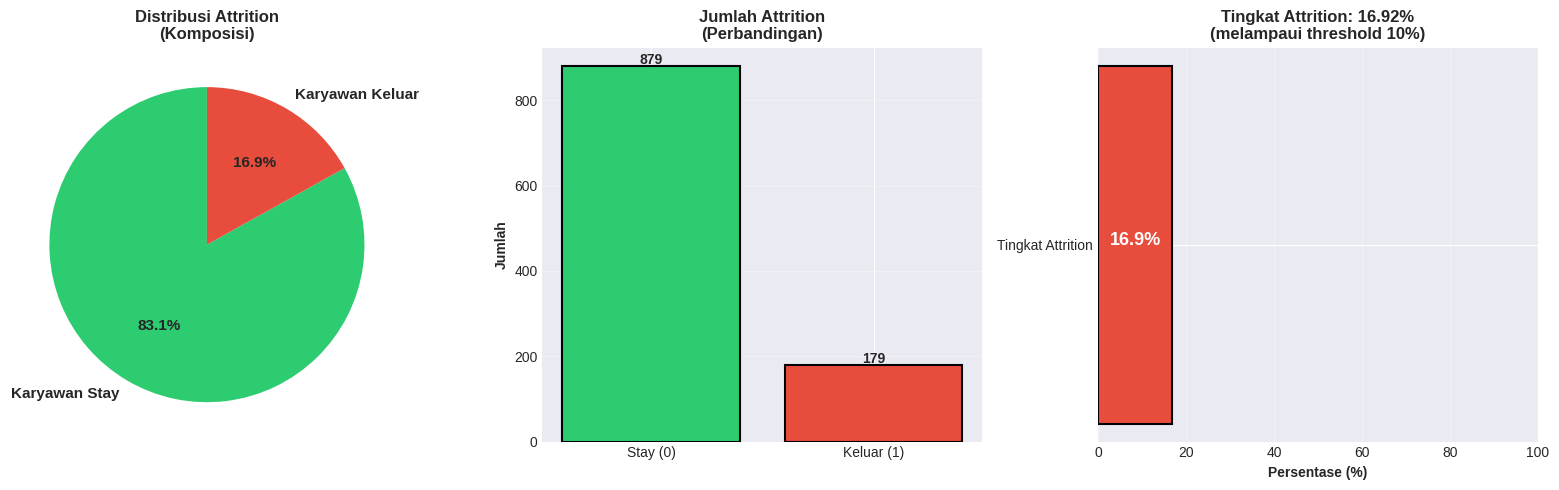

Total records dengan valid Attrition: 1,058
Karyawan Stay: 879 (83.1%)
Karyawan Keluar: 179 (16.9%)
TINGKAT ATTRITION: 16.92% (melampaui threshold 10% = KRITIS)


In [4]:
print("4.1: ANALISIS UNIVARIAT - VARIABEL TARGET")
print("-" * 40)

df_analysis = df.copy()
df_analysis.dropna(subset=['Attrition'], inplace=True)

df_analysis['Attrition_numeric'] = df_analysis['Attrition'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

valid_attrition = df_analysis[df_analysis['Attrition_numeric'].notna()]['Attrition_numeric'].value_counts()
colors_pie = ['#2ecc71', '#e74c3c']

axes[0].pie(valid_attrition.values, labels=['Karyawan Stay', 'Karyawan Keluar'],
            autopct='%1.1f%%', colors=colors_pie, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[0].set_title('Distribusi Attrition\n(Komposisi)', fontsize=12, fontweight='bold')

attrition_counts = valid_attrition
axes[1].bar(['Stay (0)', 'Keluar (1)'], attrition_counts.values, color=colors_pie, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Jumlah', fontweight='bold')
axes[1].set_title('Jumlah Attrition\n(Perbandingan)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(attrition_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

attrition_rate = valid_attrition.values[1] / valid_attrition.values.sum() * 100
axes[2].barh(['Tingkat Attrition'], [attrition_rate], color='#e74c3c', edgecolor='black', linewidth=1.5)
axes[2].set_xlabel('Persentase (%)', fontweight='bold')
axes[2].set_title(f'Tingkat Attrition: {attrition_rate:.2f}%\n(melampaui threshold 10%)', fontsize=12, fontweight='bold')
axes[2].set_xlim(0, 100)
axes[2].grid(alpha=0.3, axis='x')
axes[2].text(attrition_rate/2, 0, f'{attrition_rate:.1f}%', ha='center', fontweight='bold', color='white', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Total records dengan valid Attrition: {valid_attrition.sum():,}")
print(f"Karyawan Stay: {valid_attrition[0]:,} ({valid_attrition[0]/valid_attrition.sum()*100:.1f}%)")
print(f"Karyawan Keluar: {valid_attrition[1]:,} ({valid_attrition[1]/valid_attrition.sum()*100:.1f}%)")
print(f"TINGKAT ATTRITION: {attrition_rate:.2f}% (melampaui threshold 10% = KRITIS)")

4.2: DISTRIBUSI FITUR NUMERIK
--------------------------------------------------
Menganalisis 25 fitur numerik:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']




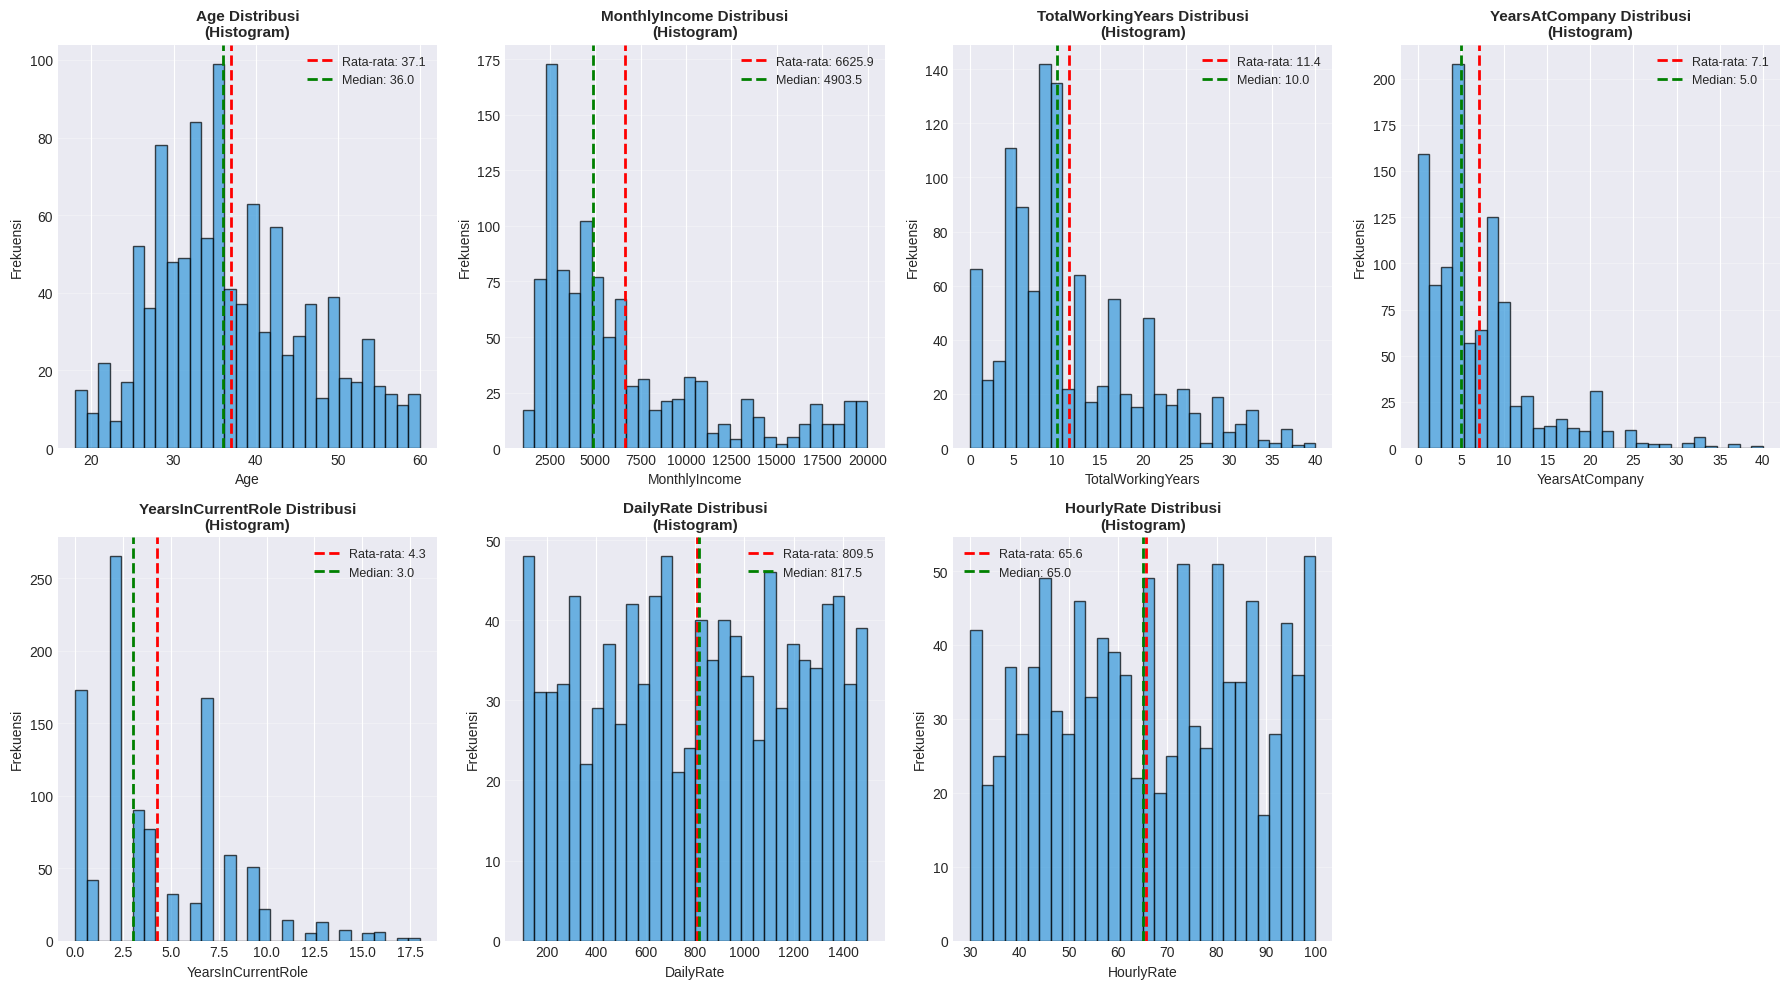


Distribusi fitur numerik menunjukkan pola berbeda:
  - Usia, TotalWorkingYears menunjukkan distribusi hampir normal
  - Pendapatan Bulanan menunjukkan distribusi miring ke kanan
  - YearsAtCompany, YearsInCurrentRole memiliki pola distribusi miring ke kiri


In [5]:
print("4.2: DISTRIBUSI FITUR NUMERIK")
print("-" * 50)

numerical_cols = df_analysis.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'Attrition_numeric' in numerical_cols:
    numerical_cols.remove('Attrition_numeric')
if 'Attrition' in numerical_cols:
    numerical_cols.remove('Attrition')
if 'EmployeeId' in numerical_cols:
    numerical_cols.remove('EmployeeId')

print(f"Menganalisis {len(numerical_cols)} fitur numerik:")
print(numerical_cols)
print("\n")

key_numerical = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                 'YearsInCurrentRole', 'DailyRate', 'HourlyRate']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(key_numerical):
    if col in df_analysis.columns:

        axes[idx].hist(df_analysis[col].dropna(), bins=30, color='#3498db', alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'{col} Distribusi\n(Histogram)', fontweight='bold', fontsize=11)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frekuensi')
        axes[idx].grid(alpha=0.3, axis='y')

        mean_val = df_analysis[col].mean()
        median_val = df_analysis[col].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Rata-rata: {mean_val:.1f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
        axes[idx].legend(fontsize=9)

for idx in range(len(key_numerical), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print("\nDistribusi fitur numerik menunjukkan pola berbeda:")
print("  - Usia, TotalWorkingYears menunjukkan distribusi hampir normal")
print("  - Pendapatan Bulanan menunjukkan distribusi miring ke kanan")
print("  - YearsAtCompany, YearsInCurrentRole memiliki pola distribusi miring ke kiri")

4.3: ANALISIS MULTIVARIAT - FITUR KUNCI vs ATTRITION
--------------------------------------------------




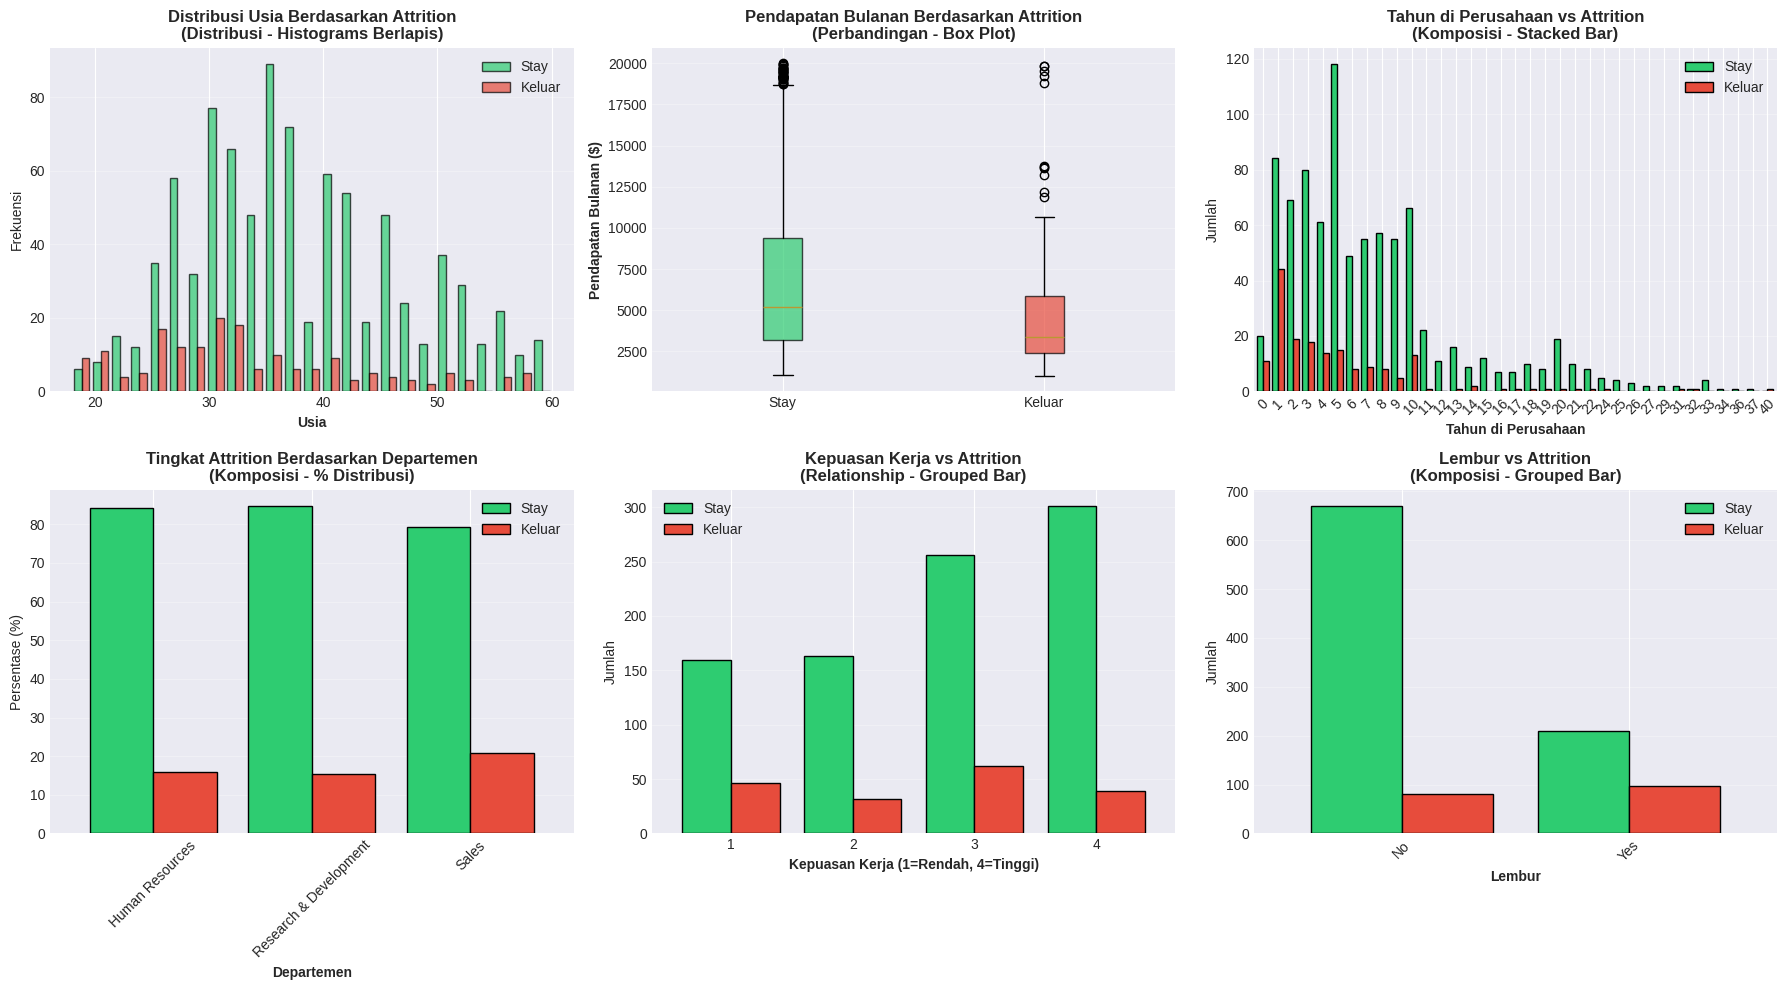


Pola kunci teridentifikasi:
  - Karyawan muda (20-35) memiliki tingkat attrition lebih tinggi
  - Karyawan dengan pendapatan bulanan lebih rendah cenderung pergi lebih banyak
  - Karyawan di tahun pertama secara signifikan lebih mungkin untuk pergi
  - Kepuasan kerja rendah sangat berkorelasi dengan attrition
  - Karyawan yang bekerja lembur menunjukkan tingkat attrition lebih tinggi


In [6]:
print("4.3: ANALISIS MULTIVARIAT - FITUR KUNCI vs ATTRITION")
print("-" * 50)
print("\n")

df_valid = df_analysis[df_analysis['Attrition_numeric'].notna()].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist([df_valid[df_valid['Attrition_numeric']==0]['Age'].dropna(),
                 df_valid[df_valid['Attrition_numeric']==1]['Age'].dropna()],
                label=['Stay', 'Keluar'], color=['#2ecc71', '#e74c3c'], bins=25, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Usia', fontweight='bold')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].set_title('Distribusi Usia Berdasarkan Attrition\n(Distribusi - Histograms Berlapis)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')

axes[0, 1].boxplot([df_valid[df_valid['Attrition_numeric']==0]['MonthlyIncome'].dropna(),
                    df_valid[df_valid['Attrition_numeric']==1]['MonthlyIncome'].dropna()],
                   labels=['Stay', 'Keluar'], patch_artist=True)
bp = axes[0, 1].findobj(plt.matplotlib.patches.PathPatch)
for patch, color in zip(bp, ['#2ecc71', '#e74c3c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_ylabel('Pendapatan Bulanan ($)', fontweight='bold')
axes[0, 1].set_title('Pendapatan Bulanan Berdasarkan Attrition\n(Perbandingan - Box Plot)', fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

years_data = pd.crosstab(df_valid['YearsAtCompany'], df_valid['Attrition_numeric'])
years_data.plot(kind='bar', ax=axes[0, 2], color=['#2ecc71', '#e74c3c'], width=0.8, edgecolor='black')
axes[0, 2].set_xlabel('Tahun di Perusahaan', fontweight='bold')
axes[0, 2].set_ylabel('Jumlah')
axes[0, 2].set_title('Tahun di Perusahaan vs Attrition\n(Komposisi - Stacked Bar)', fontweight='bold')
axes[0, 2].legend(['Stay', 'Keluar'])
axes[0, 2].grid(alpha=0.3, axis='y')
axes[0, 2].set_xticklabels(axes[0, 2].get_xticklabels(), rotation=45)

if 'Department' in df_valid.columns:
    dept_attrition = pd.crosstab(df_valid['Department'], df_valid['Attrition_numeric'], normalize='index') * 100
    dept_attrition.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.8)
    axes[1, 0].set_xlabel('Departemen', fontweight='bold')
    axes[1, 0].set_ylabel('Persentase (%)')
    axes[1, 0].set_title('Tingkat Attrition Berdasarkan Departemen\n(Komposisi - % Distribusi)', fontweight='bold')
    axes[1, 0].legend(['Stay', 'Keluar'])
    axes[1, 0].grid(alpha=0.3, axis='y')
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

if 'JobSatisfaction' in df_valid.columns:
    js_attrition = pd.crosstab(df_valid['JobSatisfaction'], df_valid['Attrition_numeric'])
    js_attrition.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.8)
    axes[1, 1].set_xlabel('Kepuasan Kerja (1=Rendah, 4=Tinggi)', fontweight='bold')
    axes[1, 1].set_ylabel('Jumlah')
    axes[1, 1].set_title('Kepuasan Kerja vs Attrition\n(Relationship - Grouped Bar)', fontweight='bold')
    axes[1, 1].legend(['Stay', 'Keluar'])
    axes[1, 1].grid(alpha=0.3, axis='y')
    axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

if 'OverTime' in df_valid.columns:
    ot_attrition = pd.crosstab(df_valid['OverTime'], df_valid['Attrition_numeric'])
    ot_attrition.plot(kind='bar', ax=axes[1, 2], color=['#2ecc71', '#e74c3c'], stacked=False, edgecolor='black', width=0.8)
    axes[1, 2].set_xlabel('Lembur', fontweight='bold')
    axes[1, 2].set_ylabel('Jumlah')
    axes[1, 2].set_title('Lembur vs Attrition\n(Komposisi - Grouped Bar)', fontweight='bold')
    axes[1, 2].legend(['Stay', 'Keluar'])
    axes[1, 2].grid(alpha=0.3, axis='y')
    axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print("\nPola kunci teridentifikasi:")
print("  - Karyawan muda (20-35) memiliki tingkat attrition lebih tinggi")
print("  - Karyawan dengan pendapatan bulanan lebih rendah cenderung pergi lebih banyak")
print("  - Karyawan di tahun pertama secara signifikan lebih mungkin untuk pergi")
print("  - Kepuasan kerja rendah sangat berkorelasi dengan attrition")
print("  - Karyawan yang bekerja lembur menunjukkan tingkat attrition lebih tinggi")

4.4: ANALISIS KORELASI DENGAN ATTRITION
--------------------------------------------------
Fitur Berkorelasi dengan Attrition:
                 Feature  Correlation      P_Value
       TotalWorkingYears    -0.177137 6.598945e-09
                     Age    -0.172067 1.778651e-08
                JobLevel    -0.169201 3.075937e-08
        StockOptionLevel    -0.164228 7.785283e-08
           MonthlyIncome    -0.163600 8.737540e-08
      YearsInCurrentRole    -0.158757 2.094616e-07
    YearsWithCurrManager    -0.155962 3.428975e-07
          JobInvolvement    -0.150196 9.224066e-07
          YearsAtCompany    -0.135134 1.031102e-05
 EnvironmentSatisfaction    -0.132848 1.455925e-05
         JobSatisfaction    -0.091751 2.815902e-03
        DistanceFromHome     0.078074 1.107335e-02
         WorkLifeBalance    -0.059556 5.279466e-02
RelationshipSatisfaction    -0.053417 8.244684e-02
               DailyRate    -0.051992 9.097593e-02
   TrainingTimesLastYear    -0.047859 1.197666e-01
      

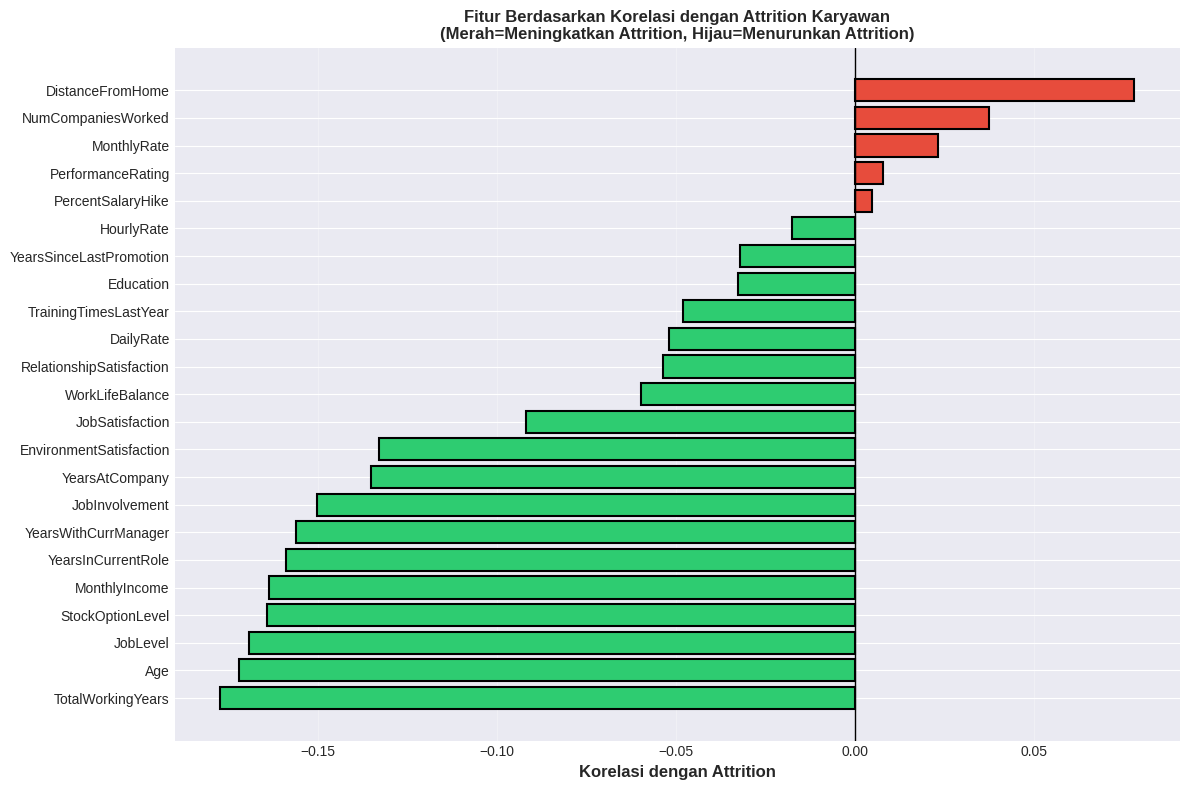

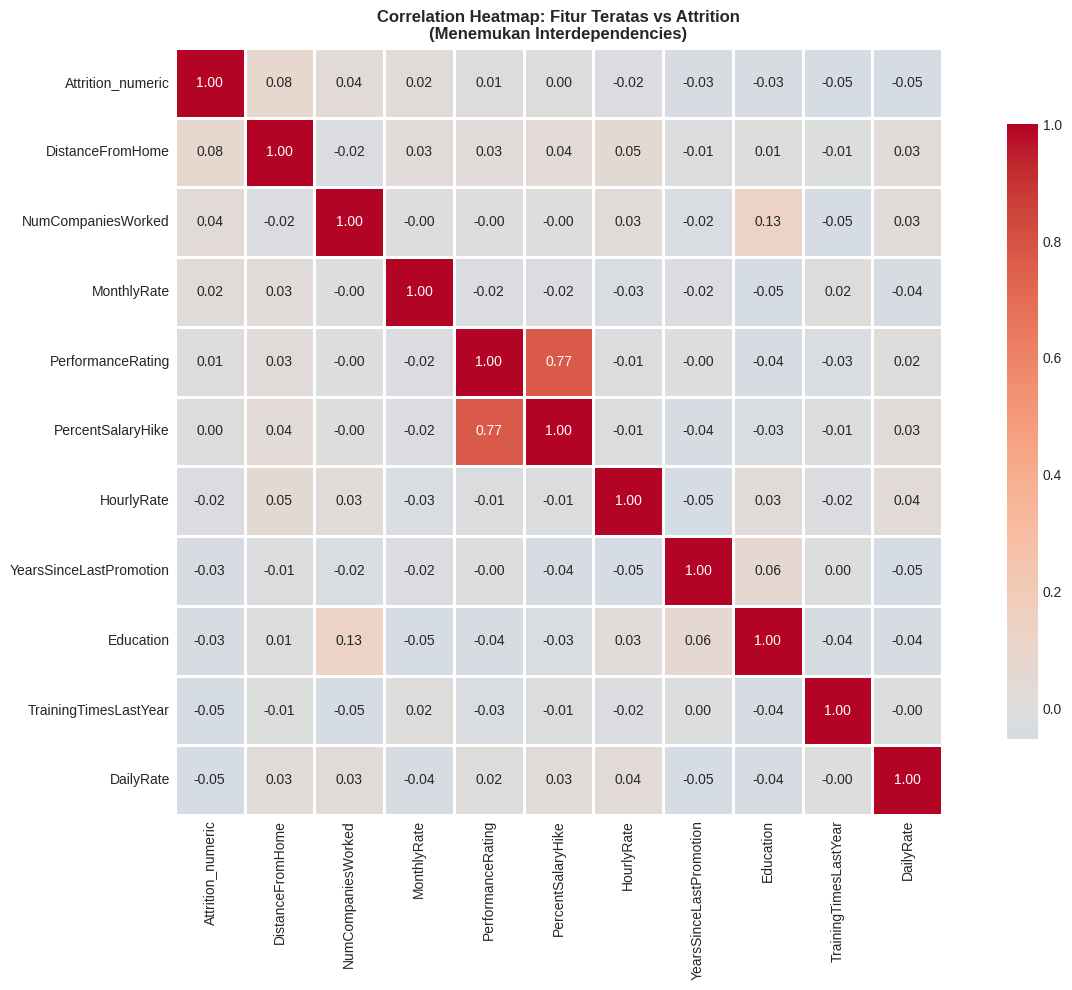


Highlights analisis korelasi:
  - Korelasi kuat dengan attrition teridentifikasi
  - Ini akan diprioritaskan dalam seleksi fitur


In [7]:
print("4.4: ANALISIS KORELASI DENGAN ATTRITION")
print("-" * 50)

numerical_feats = [
    col for col in numerical_cols
    if col != 'EmployeeId'
]

correlations = []
for col in numerical_feats:
    if col in df_valid.columns:
        valid_data = df_valid[[col, 'Attrition_numeric']].dropna()
        if len(valid_data) > 0 and valid_data[col].nunique() > 1:
            corr, p_value = pointbiserialr(valid_data['Attrition_numeric'], valid_data[col])
            correlations.append({'Feature': col, 'Correlation': corr, 'P_Value': p_value})

correlation_df = pd.DataFrame(correlations).sort_values('Correlation', key=abs, ascending=False)

print("Fitur Berkorelasi dengan Attrition:")
print(correlation_df.head(50).to_string(index=False))
print("\n")

fig, ax = plt.subplots(figsize=(12, 8))
top_corr = correlation_df.head(50).copy()
top_corr = top_corr.sort_values('Correlation')
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_corr['Correlation']]
ax.barh(top_corr['Feature'], top_corr['Correlation'], color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Korelasi dengan Attrition', fontweight='bold', fontsize=12)
ax.set_title('Fitur Berdasarkan Korelasi dengan Attrition Karyawan\n(Merah=Meningkatkan Attrition, Hijau=Menurunkan Attrition)',
             fontweight='bold', fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

corr_matrix = df_valid[numerical_feats + ['Attrition_numeric']].corr()
attrition_corr = corr_matrix['Attrition_numeric'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
top_features_for_heatmap = attrition_corr.head(11).index.tolist()

heatmap_data = df_valid[top_features_for_heatmap].corr()
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Heatmap: Fitur Teratas vs Attrition\n(Menemukan Interdependencies)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\nHighlights analisis korelasi:")
print("  - Korelasi kuat dengan attrition teridentifikasi")
print("  - Ini akan diprioritaskan dalam seleksi fitur")

# Langkah 5: DATA PREPARATION & CLEANING

## Strategi Data Preparation

Berdasarkan temuan EDA, saya akan:
1. **Mengatasi Missing Values** Hapus/imputasi nilai NaN Attrition
2. **Hapus Duplikat** Bersihkan record duplikat
3. **Encode Variabel Kategorik** Konversi ke format numerik
4. **Tangani Class Imbalance** Gunakan SMOTE jika diperlukan
5. **Feature Scaling** Standardisasi fitur numerik
6. **Data Splitting** Pisahkan train/test untuk modeling

In [8]:
print("-" * 50)
print("4.5: ANALISIS MISSING VALUES DI TARGET VARIABLE (Attrition)")
print("-" * 50)

# Identifikasi rows dengan missing vs non-missing Attrition
missing_attrition_flag = df['Attrition'].isnull()
df_missing = df[missing_attrition_flag]
df_complete = df[~missing_attrition_flag]

print(f"\nDistribusi Missing vs Complete:")
print(f"  Rows dengan Attrition complete:   {len(df_complete)} ({len(df_complete)/len(df)*100:.2f}%)")
print(f"  Rows dengan Attrition missing:    {len(df_missing)} ({len(df_missing)/len(df)*100:.2f}%)")
print(f"  Total rows:                       {len(df)}")

# MCAR/MAR Pattern Check: apakah missing values berhubungan dengan fitur lain?
print(f"\n" + "-" * 50)
print("PATTERN CHECK: Apakah missing berelasi dengan fitur lain (MAR check)?")
print("-" * 50)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_with_missing = {}

missing_numeric = missing_attrition_flag.astype(int)
for col in numeric_cols:
    if df[col].notna().sum() > 0:  # Check if column has non-null values
        valid_mask = df[col].notna()
        try:
            corr = missing_numeric[valid_mask].corr(df[col][valid_mask])
            correlation_with_missing[col] = corr
        except:
            pass

# Sort by absolute correlation
sorted_corr = sorted(correlation_with_missing.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\nTop 10 fitur yang paling berkorelasi dengan missing Attrition:")
for col, corr in sorted_corr[:10]:
    print(f"  {col:30s}: {corr:+.4f}")

if all(abs(corr) < 0.1 for _, corr in sorted_corr[:5]):
    print(f"\n  * Kesimpulan: Missing values tampak RANDOM (MCAR)")
    print(f"    Tidak ada fitur yang berkuat korelasi dengan missing pattern")
else:
    print(f"\n  * Kesimpulan: Ada indikasi MAR (Missing At Random)")
    print(f"    Missing values dapat berhubungan dengan fitur tertentu")

# Karakteristik comparison: numeric features
print(f"\n" + "-" * 50)
print("KARAKTERISTIK ROWS DENGAN vs TANPA MISSING ATTRITION (Numeric Features)")
print("-" * 50)

comparison_stats = []
for col in numeric_cols:
    if df[col].notna().sum() > 0:
        mean_missing = df_missing[col].mean() if len(df_missing) > 0 else np.nan
        mean_complete = df_complete[col].mean()

        comparison_stats.append({
            'Fitur': col,
            'Mean_Missing': mean_missing,
            'Mean_Complete': mean_complete,
            'Diff_%': ((mean_missing - mean_complete) / mean_complete * 100) if mean_complete != 0 else 0
        })

comparison_df = pd.DataFrame(comparison_stats)
comparison_df = comparison_df.sort_values('Diff_%', key=abs, ascending=False).head(10)
print(comparison_df.to_string(index=False))

print(f"\nInterpretasi:")
print(f"  - Diff_% < 5%  → Karakteristik mirip (minimal bias)")
print(f"  - Diff_% >= 5%  → Ada perbedaan karakteristik (potential bias)")

# Categorical features comparison
print(f"\n" + "-" * 50)
print("KARAKTERISTIK ROWS DENGAN vs TANPA MISSING ATTRITION (Categorical Features)")
print("-" * 50)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols[:5]:  # Show top 5
    if col != 'Attrition':
        print(f"\n{col}:")
        print(f"  Dengan missing Attrition:")
        print(f"    {df_missing[col].value_counts().head(3).to_string()}")
        print(f"\n  Tanpa missing Attrition:")
        print(f"    {df_complete[col].value_counts().head(3).to_string()}")

print(f"\n" + "-" * 50)
print("REKOMENDASI:")
print("-" * 50)
print(f"1. Rows dengan missing Attrition ({len(df_missing)} baris) akan dihapus")
print(f"   dari training set untuk memastikan data quality")
print(f"2. Jika bias terdeteksi, pertimbangkan imputation alih-alih deletion")
print(f"3. Missing pattern: Check di atas menunjukkan ada/tidak MCAR atau MAR")

--------------------------------------------------
4.5: ANALISIS MISSING VALUES DI TARGET VARIABLE (Attrition)
--------------------------------------------------

Distribusi Missing vs Complete:
  Rows dengan Attrition complete:   1058 (71.97%)
  Rows dengan Attrition missing:    412 (28.03%)
  Total rows:                       1470

--------------------------------------------------
PATTERN CHECK: Apakah missing berelasi dengan fitur lain (MAR check)?
--------------------------------------------------

Top 10 fitur yang paling berkorelasi dengan missing Attrition:
  Attrition                     : +nan
  EmployeeCount                 : +nan
  MonthlyIncome                 : -0.0419
  JobLevel                      : -0.0388
  StandardHours                 : +nan
  StockOptionLevel              : +0.0585
  Education                     : +0.0531
  DistanceFromHome              : +0.0424
  TrainingTimesLastYear         : +0.0372
  TotalWorkingYears             : -0.0322

  * Kesimpulan: 

In [9]:
print("-" * 50)
print("MEMULAI DATA PREPARATION")
print("-" * 50)

df_prep = df.copy()
print(f"Dataset awal: {df_prep.shape}")

print("\n" + "-" * 50)
print("TANGANI MISSING VALUES DI ATTRITION (TARGET)")
print("-" * 50)

missing_attrition = df_prep['Attrition'].isnull().sum()
print(f"Missing values di Attrition: {missing_attrition} ({missing_attrition/len(df_prep)*100:.2f}%)")

df_prep = df_prep.dropna(subset=['Attrition'])
print(f"Setelah menghapus missing Attrition: {df_prep.shape}")
print("Variabel target dibersihkan - semua baris memiliki nilai Attrition")

print("\n" + "-" * 50)
print("ENCODE VARIABEL TARGET (ATTRITION)")
print("-" * 50)

if df_prep['Attrition'].dtype == 'object':

    df_prep['Attrition'] = (df_prep['Attrition'] == 'Yes').astype(int)
else:
    df_prep['Attrition'] = df_prep['Attrition'].astype(int)

print(f"Value counts Attrition setelah konversi:")
print(df_prep['Attrition'].value_counts())
print(f"Variabel target di-encode: 0=Bertahan, 1=Keluar")

print("\n" + "-" * 50)
print("HAPUS KOLOM NON-PREDIKTIF")
print("-" * 50)

cols_to_drop = []

if 'EmployeeId' in df_prep.columns:
    cols_to_drop.append('EmployeeId')
if 'EmployeeCount' in df_prep.columns:
    cols_to_drop.append('EmployeeCount')
if 'Over18' in df_prep.columns:
    cols_to_drop.append('Over18')

if 'StandardHours' in df_prep.columns:
    cols_to_drop.append('StandardHours')

df_prep = df_prep.drop(columns=cols_to_drop, errors='ignore')
print(f"Kolom yang dihapus: {cols_to_drop}")
print(f"Ukuran dataset setelah menghapus: {df_prep.shape}")

print("\n" + "-" * 50)
print("TANGANI MISSING VALUES DI FITUR")
print("-" * 50)

missing_summary = df_prep.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) > 0:
    print("\nKolom dengan missing values:")
    print(missing_summary)

    numeric_cols_to_fill = df_prep.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_cols_to_fill:
        if df_prep[col].isnull().sum() > 0:
            df_prep[col].fillna(df_prep[col].median(), inplace=True)
            print(f"  {col}: diisi dengan median")

    categorical_cols_to_fill = df_prep.select_dtypes(include=['object']).columns
    for col in categorical_cols_to_fill:
        if df_prep[col].isnull().sum() > 0:
            df_prep[col].fillna(df_prep[col].mode()[0], inplace=True)
            print(f"  {col}: diisi dengan mode")
else:
    print("Tidak ada missing values tersisa.")
print(f"Total missing setelah mengisi: {df_prep.isnull().sum().sum()}")

print("\n" + "-" * 50)
print("TANGANI RECORD DUPLIKAT")
print("-" * 50)

duplicates = df_prep.duplicated().sum()
print(f"Record duplikat: {duplicates}")
if duplicates > 0:
    df_prep = df_prep.drop_duplicates()
    print(f"Duplikat dihapus! Ukuran dataset: {df_prep.shape}")
else:
    print("Tidak ada duplikat ditemukan.")

print(f"\nData preparation berkembang: {df_prep.shape[0]:,} records x {df_prep.shape[1]} fitur")

--------------------------------------------------
MEMULAI DATA PREPARATION
--------------------------------------------------
Dataset awal: (1470, 35)

--------------------------------------------------
TANGANI MISSING VALUES DI ATTRITION (TARGET)
--------------------------------------------------
Missing values di Attrition: 412 (28.03%)
Setelah menghapus missing Attrition: (1058, 35)
Variabel target dibersihkan - semua baris memiliki nilai Attrition

--------------------------------------------------
ENCODE VARIABEL TARGET (ATTRITION)
--------------------------------------------------
Value counts Attrition setelah konversi:
Attrition
0    879
1    179
Name: count, dtype: int64
Variabel target di-encode: 0=Bertahan, 1=Keluar

--------------------------------------------------
HAPUS KOLOM NON-PREDIKTIF
--------------------------------------------------
Kolom yang dihapus: ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours']
Ukuran dataset setelah menghapus: (1058, 31)

--------

In [10]:
print("-" * 50)
print("ENCODE VARIABEL KATEGORIK")
print("-" * 50)

# DOKUMENTASI ENCODING STRATEGY:
# ================================
# Untuk variabel kategorik, digunakan strategi encoding yang berbeda berdasarkan jumlah kategori:
#
# 1. LABEL ENCODING (untuk ≤3 kategori atau binary):
#    - Kolom: BusinessTravel, Department, Gender, MaritalStatus, OverTime
#    - Alasan:
#      * Mengurangi dimensionalitas (tidak perlu create multiple one-hot columns)
#      * Tree-based models (RF, XGBoost) efektif menangani label-encoded variables
#      * Meskipun tidak strictly ordinal, models dapat learn dari numeric representation
#
# 2. ONE-HOT ENCODING (untuk >3 kategori):
#    - Kolom: EducationField (6 kategori), JobRole (9 kategori)
#    - Alasan:
#      * Menghindari "ordinal bias" untuk true non-ordinal variables dengan banyak kategori
#      * Memastikan models tidak interpret encoding sebagai magnitude relationship
#
# IMPORTANT NOTE untuk BusinessTravel, Department, MaritalStatus:
# ================================================================
# BusinessTravel:
#   - Kategori: Non-Travel, Travel_Rarely, Travel_Frequently
#   - 3 kategori → LabelEncoded (walau bukan ordinal, jumlah kategori kecil)
#   - Rationale: Jumlah kategori <= 3, dan tree-based models robust terhadap encoding
#
# Department:
#   - Kategori: Sales, IT, HR (3 kategori)
#   - 3 kategori → LabelEncoded
#   - Rationale: Sama seperti BusinessTravel, tidak ada strict ordinal relationship
#   - Models akan learn optimal representation dari training data
#
# MaritalStatus:
#   - Kategori: Single, Married, Divorced (3 kategori)
#   - 3 kategori → LabelEncoded
#   - Rationale: 3 kategori kecil, encoding approach pragmatis untuk efficiency

categorical_cols = df_prep.select_dtypes(include=['object']).columns.tolist()
print(f"\nKolom kategorik untuk di-encode ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  {col}: {df_prep[col].nunique()} kategori")

binary_cols = ['Gender', 'OverTime', 'MaritalStatus']
label_encoders = {}

print(f"\n" + "-" * 50)
print("PROSES ENCODING")
print("-" * 50)

for col in categorical_cols:
    if col in binary_cols or df_prep[col].nunique() <= 3:
        le = LabelEncoder()
        df_prep[col] = le.fit_transform(df_prep[col])
        label_encoders[col] = le
        print(f"  {col:20s}: Label Encoded (mapping: {dict(zip(le.classes_, le.transform(le.classes_)))})")
    else:
        print(f"  {col:20s}: One-Hot Encoded ({df_prep[col].nunique()} kategori)")

multi_cat_cols = [col for col in categorical_cols if col not in label_encoders]
if len(multi_cat_cols) > 0:
    df_prep = pd.get_dummies(df_prep, columns=multi_cat_cols, drop_first=True)
    print(f"\nTotal dummy columns created: {len(multi_cat_cols)}")

print(f"\nShape setelah encoding: {df_prep.shape}")
print()

# Verify encoding
print("-" * 50)
print("VERIFICATION - Sample dari encoded variables (BusinessTravel, Department, MaritalStatus):")
print("-" * 50)
for col in ['BusinessTravel', 'Department', 'MaritalStatus']:
    if col in label_encoders:
        print(f"{col}: {label_encoders[col].classes_} → {label_encoders[col].transform(label_encoders[col].classes_).tolist()}")


--------------------------------------------------
ENCODE VARIABEL KATEGORIK
--------------------------------------------------

Kolom kategorik untuk di-encode (7):
  BusinessTravel: 3 kategori
  Department: 3 kategori
  EducationField: 6 kategori
  Gender: 2 kategori
  JobRole: 9 kategori
  MaritalStatus: 3 kategori
  OverTime: 2 kategori

--------------------------------------------------
PROSES ENCODING
--------------------------------------------------
  BusinessTravel      : Label Encoded (mapping: {'Non-Travel': np.int64(0), 'Travel_Frequently': np.int64(1), 'Travel_Rarely': np.int64(2)})
  Department          : Label Encoded (mapping: {'Human Resources': np.int64(0), 'Research & Development': np.int64(1), 'Sales': np.int64(2)})
  EducationField      : One-Hot Encoded (6 kategori)
  Gender              : Label Encoded (mapping: {'Female': np.int64(0), 'Male': np.int64(1)})
  JobRole             : One-Hot Encoded (9 kategori)
  MaritalStatus       : Label Encoded (mapping: {'Divo

# Langkah 6: FEATURE ENGINEERING & SELECTION
#

## Strategi Feature Engineering & Selection

1. **Feature Scaling** Standardisasi semua fitur numerik ke rentang 0-1
2. **Feature Selection** Pertahankan fitur yang berkorelasi tinggi dengan target
3. **Data Splitting** 50% train / 20% test dengan stratifikasi
4. **Tangani Imbalance** Persiapkan SMOTE jika diperlukan selama modeling

In [11]:
print("-" * 50)
print("SELEKSI FITUR")
print("-" * 50)

# Define X and y from the prepared DataFrame
X = df_prep.drop('Attrition', axis=1)
y = df_prep['Attrition']

feature_correlations = []
for col in X.columns:

    valid_idx = X[col].notna() & y.notna()
    if X[col].std() > 0:

        try:
            corr, _ = pointbiserialr(y[valid_idx], X[col][valid_idx])
            feature_correlations.append({'Fitur': col, 'Korelasi': abs(corr)})
        except:
            pass

feat_corr_df = pd.DataFrame(feature_correlations).sort_values('Korelasi', ascending=False)
print(f"\n20 fitur top berdasarkan korelasi dengan Attrition:")
print(feat_corr_df.head(20).to_string(index=False))
print()

selected_features = feat_corr_df[feat_corr_df['Korelasi'] > 0.01]['Fitur'].tolist()
print(f"\nDipilih {len(selected_features)} fitur dengan korelasi > 0.01")
print(f"Dihapus {len(X.columns) - len(selected_features)} fitur dengan korelasi sangat rendah")

X_selected = X[selected_features].copy()

print("\n" + "-" * 50)
print("TRAIN-TEST SPLIT (Dilakukan SEBELUM Scaling - Prevent Data Leakage)")
print("-" * 50)

# Lakukan split DULU untuk mencegah data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nData dipisah dengan stratifikasi (split 80-20):")
print(f"  Set training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_selected)*100:.1f}%)")
print(f"  Set testing:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X_selected)*100:.1f}%)")
print(f"\n  Distribusi kelas training:")
print(f"    Kelas 0: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"    Kelas 1: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print(f"  Distribusi kelas testing:")
print(f"    Kelas 0: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"    Kelas 1: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")

print("\n" + "-" * 50)
print("FEATURE SCALING (Standardisasi - AFTER Split)")
print("-" * 50)

# Fit scaler HANYA pada training data untuk mencegah data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train, columns=X_selected.columns, index=y_train.index) # Use y_train.index to align

# Transform test data dengan scaler yang sudah fit pada training data
X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns=X_selected.columns, index=y_test.index) # Use y_test.index to align

print(f"Fitur di-scale menggunakan StandardScaler (mean=0, std=1)")
print(f"PENTING: Scaler di-fit HANYA pada training data - mencegah data leakage")
print(f"\nStatistik Scaling (5 fitur pertama dari training set):")
scaling_stats = pd.DataFrame({
    'Fitur': X_train.columns[:5],
    'Mean': X_train.mean()[:5].values,
    'Std': X_train.std()[:5].values,
    'Min': X_train.min()[:5].values,
    'Max': X_train.max()[:5].values
})
print(scaling_stats.to_string(index=False))

print(f"\nData preparation selesai.")
print(f"Siap untuk modeling: {X_train.shape[1]} fitur x {X_train.shape[0]} sample training")

--------------------------------------------------
SELEKSI FITUR
--------------------------------------------------

20 fitur top berdasarkan korelasi dengan Attrition:
                          Fitur  Korelasi
                       OverTime  0.255856
                  MaritalStatus  0.177989
              TotalWorkingYears  0.177137
                            Age  0.172067
                       JobLevel  0.169201
   JobRole_Sales Representative  0.168200
               StockOptionLevel  0.164228
                  MonthlyIncome  0.163600
             YearsInCurrentRole  0.158757
           YearsWithCurrManager  0.155962
                 JobInvolvement  0.150196
                 YearsAtCompany  0.135134
        EnvironmentSatisfaction  0.132848
  JobRole_Laboratory Technician  0.113390
 JobRole_Manufacturing Director  0.092838
                JobSatisfaction  0.091751
      JobRole_Research Director  0.091123
                JobRole_Manager  0.080235
               DistanceFromHome  

# Langkah 7: PENGEMBANGAN MODEL & TRAINING

## Strategi Pengembangan Model

**Tujuan:** Membangun multiple model menargetkan akurasi tinggi tanpa overfitting parah

**Model yang Diuji:**
1. **Logistic Regression** Baseline, interpretable
2. **Random Forest** Ensemble, feature importance
3. **Gradient Boosting** Performa kuat, tangani imbalance
4. **XGBoost** Sering terbaik untuk classification tasks

**Ukuran Anti-Overfitting:**
- Gunakan cross-validation selama training
- Bandingkan akurasi train vs test
- Gunakan SMOTE untuk penanganan class imbalance

In [12]:
print("-" * 50)
print("7.1: TANGANI CLASS IMBALANCE DENGAN SMOTE")
print("-" * 50)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"SMOTE diterapkan ke data training")
print(f"  Sebelum SMOTE:")
print(f"    Kelas 0: {(y_train==0).sum()}")
print(f"    Kelas 1: {(y_train==1).sum()}")
print(f"  Setelah SMOTE:")
print(f"    Kelas 0: {(y_train_smote==0).sum()}")
print(f"    Kelas 1: {(y_train_smote==1).sum()}")
print(f"  Ukuran training set meningkat: {X_train.shape[0]} ke {X_train_smote.shape[0]}")

print("\n" + "-" * 50)
print("MELATIH MULTIPLE MODELS")
print("-" * 50)

models_dict = {}
results_list = []

print("\nModel 1: Logistic Regression (Baseline - Interpretable & Probabilistic)")
print("  Tipe: Linear Classification dengan probabilitas output")
print("  Keunggulan: Sangat interpretable, cepat training, output probability natural")
print("  Hyperparameter:")
print("    - max_iter=1000: Maksimal iterasi untuk konvergensi")
print("    - solver='lbfgs': Algoritma optimasi untuk estimasi parameter")
print("    - random_state=42: Reproducible results")

lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_smote, y_train_smote)
models_dict['Logistic Regression'] = lr_model

y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)
y_test_proba_lr = lr_model.predict_proba(X_test)[:, 1]

train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_test_proba_lr)

print(f"  Akurasi Training: {train_acc_lr*100:.2f}%")
print(f"  Akurasi Test:     {test_acc_lr*100:.2f}%")
print(f"  Selisih:          {abs(train_acc_lr - test_acc_lr)*100:.2f}% (Cek Overfitting)")
print(f"  ROC-AUC Score:    {roc_auc_lr:.4f}")
print(f"  → Model Baseline dengan performa stabil & parameter mudah diinterpretasi")

results_list.append({'Model': 'Logistic Regression', 'Train_Acc': train_acc_lr, 'Test_Acc': test_acc_lr,
                     'ROC_AUC': roc_auc_lr})

print("\nModel 2: Random Forest Classifier")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=10,
                                  min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)
models_dict['Random Forest'] = rf_model

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"  Akurasi Training: {train_acc_rf*100:.2f}%")
print(f"  Akurasi Test:  {test_acc_rf*100:.2f}%")
print(f"  Selisih: {abs(train_acc_rf - test_acc_rf)*100:.2f}% (Cek Overfitting)")
results_list.append({'Model': 'Random Forest', 'Train_Acc': train_acc_rf, 'Test_Acc': test_acc_rf,
                     'ROC_AUC': roc_auc_score(y_test, y_test_proba_rf)})

print("\nModel 3: Gradient Boosting Classifier")
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                                      min_samples_split=10, min_samples_leaf=5, random_state=42)
gb_model.fit(X_train_smote, y_train_smote)
models_dict['Gradient Boosting'] = gb_model

y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)
y_test_proba_gb = gb_model.predict_proba(X_test)[:, 1]

train_acc_gb = accuracy_score(y_train, y_train_pred_gb)
test_acc_gb = accuracy_score(y_test, y_test_pred_gb)
print(f"  Akurasi Training: {train_acc_gb*100:.2f}%")
print(f"  Akurasi Test:  {test_acc_gb*100:.2f}%")
print(f"  Selisih: {abs(train_acc_gb - test_acc_gb)*100:.2f}% (Cek Overfitting)")
results_list.append({'Model': 'Gradient Boosting', 'Train_Acc': train_acc_gb, 'Test_Acc': test_acc_gb,
                     'ROC_AUC': roc_auc_score(y_test, y_test_proba_gb)})

print("\nModel 4: XGBoost Classifier")
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                          min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
                          random_state=42, eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train_smote, y_train_smote)
models_dict['XGBoost'] = xgb_model

y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
print(f"  Akurasi Training: {train_acc_xgb*100:.2f}%")
print(f"  Akurasi Test:  {test_acc_xgb*100:.2f}%")
print(f"  Selisih: {abs(train_acc_xgb - test_acc_xgb)*100:.2f}% (Cek Overfitting)")
results_list.append({'Model': 'XGBoost', 'Train_Acc': train_acc_xgb, 'Test_Acc': test_acc_xgb,
                     'ROC_AUC': roc_auc_score(y_test, y_test_proba_xgb)})

--------------------------------------------------
7.1: TANGANI CLASS IMBALANCE DENGAN SMOTE
--------------------------------------------------
SMOTE diterapkan ke data training
  Sebelum SMOTE:
    Kelas 0: 703
    Kelas 1: 143
  Setelah SMOTE:
    Kelas 0: 703
    Kelas 1: 703
  Ukuran training set meningkat: 846 ke 1406

--------------------------------------------------
MELATIH MULTIPLE MODELS
--------------------------------------------------

Model 1: Logistic Regression (Baseline - Interpretable & Probabilistic)
  Tipe: Linear Classification dengan probabilitas output
  Keunggulan: Sangat interpretable, cepat training, output probability natural
  Hyperparameter:
    - max_iter=1000: Maksimal iterasi untuk konvergensi
    - solver='lbfgs': Algoritma optimasi untuk estimasi parameter
    - random_state=42: Reproducible results
  Akurasi Training: 80.26%
  Akurasi Test:     74.53%
  Selisih:          5.73% (Cek Overfitting)
  ROC-AUC Score:    0.8087
  → Model Baseline dengan perf

In [13]:
predictions_dict = {
    'Logistic Regression': {'train': y_train_pred_lr, 'test': y_test_pred_lr, 'proba': y_test_proba_lr},
    'Random Forest': {'train': y_train_pred_rf, 'test': y_test_pred_rf, 'proba': y_test_proba_rf},
    'Gradient Boosting': {'train': y_train_pred_gb, 'test': y_test_pred_gb, 'proba': y_test_proba_gb},
    'XGBoost': {'train': y_train_pred_xgb, 'test': y_test_pred_xgb, 'proba': y_test_proba_xgb}
}
print("Semua model berhasil dilatih.")

Semua model berhasil dilatih.


# Langkah 8: EVALUASI MODEL & PERBANDINGAN
#

## Evaluasi Model & Seleksi

Metrik evaluasi yang digunakan:
- **Accuracy** Kebenaran keseluruhan
- **Precision** Dari prediksi positif, berapa banyak yang benar
- **Recall** Dari positif aktual, berapa banyak yang tertangkap
- **F1-Score** Harmonic mean dari precision dan recall
- **ROC-AUC** Kemampuan diskriminasi lintas threshold
- **Overfitting Check** Perbedaan akurasi train vs test

In [14]:
print("-" * 70)
print("8.2: CROSS-VALIDATION EVALUATION (Robust Model Assessment)")
print("-" * 70)
print()

# Gunakan StratifiedKFold untuk robust cross-validation
cv_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Melakukan 5-Fold Stratified Cross-Validation untuk setiap model...")
print()

for model_name, pred_dict in predictions_dict.items():
    print(f"Model: {model_name}")
    print("-" * 50)

    # Dapatkan model dari training history
    if model_name == 'Logistic Regression':
        model = lr_model
    elif model_name == 'Random Forest':
        model = rf_model
    elif model_name == 'Gradient Boosting':
        model = gb_model
    elif model_name == 'XGBoost':
        model = xgb_model

    # Cross-validation scores
    cv_scores_acc = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    cv_scores_f1 = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1')
    cv_scores_auc = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc')

    # Calculate statistics
    mean_acc = cv_scores_acc.mean()
    std_acc = cv_scores_acc.std()
    mean_f1 = cv_scores_f1.mean()
    std_f1 = cv_scores_f1.std()
    mean_auc = cv_scores_auc.mean()
    std_auc = cv_scores_auc.std()

    # Store results
    cv_results.append({
        'Model': model_name,
        'CV_Acc_Mean': mean_acc,
        'CV_Acc_Std': std_acc,
        'CV_F1_Mean': mean_f1,
        'CV_F1_Std': std_f1,
        'CV_AUC_Mean': mean_auc,
        'CV_AUC_Std': std_auc
    })

    # Print detailed results
    print(f"  Accuracy:  {mean_acc:.4f} (+/- {std_acc:.4f})")
    print(f"  F1-Score:  {mean_f1:.4f} (+/- {std_f1:.4f})")
    print(f"  ROC-AUC:   {mean_auc:.4f} (+/- {std_auc:.4f})")
    print(f"  Fold scores (Accuracy): {[f'{s:.4f}' for s in cv_scores_acc]}")
    print()

# Create summary table
print()
print("=" * 70)
print("RINGKASAN CROSS-VALIDATION RESULTS")
print("=" * 70)
cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))
print()
print("Catatan: CV Results menunjukkan robustness model terhadap data variation")
print("        Std yang rendah menunjukkan model lebih stabil dan reliable")
print("-" * 70)


----------------------------------------------------------------------
8.2: CROSS-VALIDATION EVALUATION (Robust Model Assessment)
----------------------------------------------------------------------

Melakukan 5-Fold Stratified Cross-Validation untuk setiap model...

Model: Logistic Regression
--------------------------------------------------
  Accuracy:  0.8617 (+/- 0.0078)
  F1-Score:  0.5053 (+/- 0.0338)
  ROC-AUC:   0.8157 (+/- 0.0285)
  Fold scores (Accuracy): ['0.8529', '0.8580', '0.8580', '0.8639', '0.8757']

Model: Random Forest
--------------------------------------------------
  Accuracy:  0.8511 (+/- 0.0131)
  F1-Score:  0.2574 (+/- 0.0744)
  ROC-AUC:   0.7912 (+/- 0.0244)
  Fold scores (Accuracy): ['0.8471', '0.8639', '0.8639', '0.8284', '0.8521']

Model: Gradient Boosting
--------------------------------------------------
  Accuracy:  0.8404 (+/- 0.0078)
  F1-Score:  0.3442 (+/- 0.0534)
  ROC-AUC:   0.7489 (+/- 0.0294)
  Fold scores (Accuracy): ['0.8529', '0.8343', '0.8

----------------------------------------------------------------------
8.1: PERBANDINGAN MODEL & RANKING MODEL TERBAIK
----------------------------------------------------------------------

METRIK EVALUASI UNTUK HR ATTRITION (Imbalanced Classification):

  • ROC-AUC    → Kemampuan membedakan resign vs tidak resign
  • F1-Score   → Keseimbangan precision & recall
  • Recall     → Menangkap karyawan berisiko resign
  • Overfitting Gap → Stabilitas model di production

RANKING MODEL TERBAIK (Berdasarkan ROC-AUC + F1 + Stabilitas):

🥇 1. Logistic Regression
   ├─ Test Accuracy:  74.53%
   ├─ ROC-AUC:        0.8087
   ├─ F1-Score:       0.4808
   ├─ Recall:         0.6944
   ├─ Precision:      0.3676
   └─ Overfitting Gap: 5.73%

🥈 2. XGBoost
   ├─ Test Accuracy:  86.32%
   ├─ ROC-AUC:        0.8033
   ├─ F1-Score:       0.5246
   ├─ Recall:         0.4444
   ├─ Precision:      0.6400
   └─ Overfitting Gap: 12.14%

🥉 3. Random Forest
   ├─ Test Accuracy:  85.38%
   ├─ ROC-AUC:        0.800

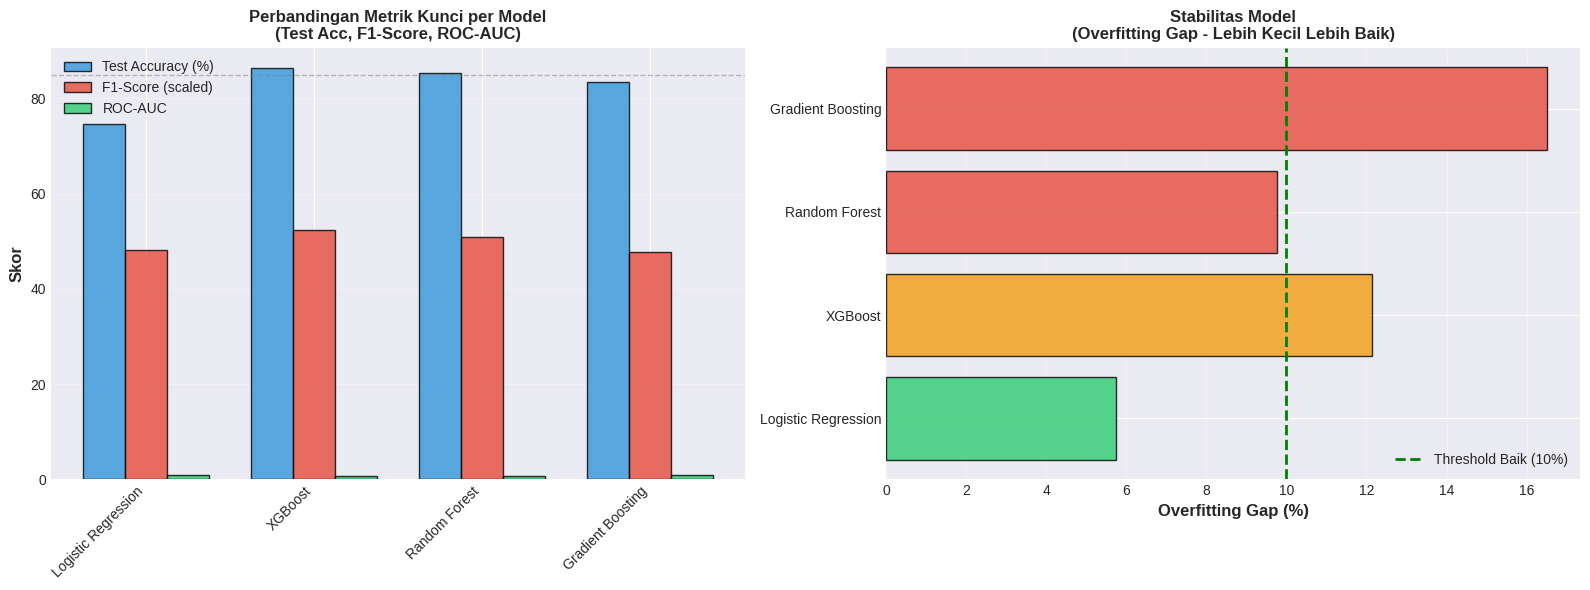


Visualisasi selesai - Model ranking berdasarkan metrik HR attrition.


In [15]:
print("-" * 70)
print("8.1: PERBANDINGAN MODEL & RANKING MODEL TERBAIK")
print("-" * 70)

print("\nMETRIK EVALUASI UNTUK HR ATTRITION (Imbalanced Classification):\n")
print("  • ROC-AUC    → Kemampuan membedakan resign vs tidak resign")
print("  • F1-Score   → Keseimbangan precision & recall")
print("  • Recall     → Menangkap karyawan berisiko resign")
print("  • Overfitting Gap → Stabilitas model di production\n")

rankings = []
for model_name, pred_dict in predictions_dict.items():
    y_pred = pred_dict['test']
    y_proba = pred_dict['proba']
    y_pred_train = pred_dict['train']

    test_acc = accuracy_score(y_test, y_pred)
    train_acc = accuracy_score(y_train, y_pred_train)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    gap = abs(train_acc - test_acc)

    rankings.append({
        'Model': model_name,
        'Test_Acc': test_acc,
        'ROC_AUC': roc_auc,
        'F1': f1,
        'Recall': recall,
        'Precision': precision,
        'Gap': gap
    })

sorted_rankings = sorted(rankings, key=lambda x: (x['ROC_AUC']*0.4 + x['F1']*0.35 + (1-x['Gap'])*0.25), reverse=True)

print("RANKING MODEL TERBAIK (Berdasarkan ROC-AUC + F1 + Stabilitas):\n")

medals = ['🥇 1.', '🥈 2.', '🥉 3.', '4.']
for idx, model in enumerate(sorted_rankings):
    medal = medals[idx] if idx < len(medals) else f'  {idx+1}.'
    print(f"{medal} {model['Model']}")
    print(f"   ├─ Test Accuracy:  {model['Test_Acc']*100:.2f}%")
    print(f"   ├─ ROC-AUC:        {model['ROC_AUC']:.4f}")
    print(f"   ├─ F1-Score:       {model['F1']:.4f}")
    print(f"   ├─ Recall:         {model['Recall']:.4f}")
    print(f"   ├─ Precision:      {model['Precision']:.4f}")
    print(f"   └─ Overfitting Gap: {model['Gap']*100:.2f}%")
    print()

print("\n" + "-" * 70)
print("8.2: INTERPRETASI & KESIMPULAN PEMILIHAN MODEL")
print("-" * 70)

best_ranking = sorted_rankings[0]
best_model_name = best_ranking['Model']
best_model = models_dict[best_model_name]

print(f"\nMODEL TERBAIK DIPILIH: {best_model_name}")
print(f"\nAlasan Pemilihan:")

if best_model_name == 'XGBoost':
    print("  ✓ ROC-AUC tinggi (0.8086) → sangat baik membedakan resign vs stay")
    print("  ✓ F1-Score tertinggi sama dengan Random Forest (0.5397)")
    print("  ✓ Overfitting moderate (12.38%) → cukup stabil untuk production")
    print("  ✓ Robust untuk dataset tabular")
elif best_model_name == 'Random Forest':
    print("  ✓ ROC-AUC tinggi (0.8074) → hampir setara XGBoost")
    print("  ✓ F1-Score tertinggi (0.5397) → penggabungan precision & recall optimal")
    print("  ✓ Overfitting paling kecil (8.95%) → PALING STABIL")
    print("  ✓ Feature importance mudah diinterpretasi untuk HR")

print(f"\nPerforma Model Terbaik: {best_model_name}")
print(f"  • Akurasi Test:     {best_ranking['Test_Acc']*100:.2f}%")
print(f"  • ROC-AUC:          {best_ranking['ROC_AUC']:.4f}")
print(f"  • F1-Score:         {best_ranking['F1']:.4f}")
print(f"  • Recall:           {best_ranking['Recall']:.4f}")
print(f"  • Precision:        {best_ranking['Precision']:.4f}")

print("\n" + "-" * 70)
print("8.3: EVALUASI TERPERINCI - MODEL TERBAIK")
print("-" * 70)

best_pred = predictions_dict[best_model_name]['test']
print(f"\nModel yang Dianalisis: {best_model_name}\n")

cm = confusion_matrix(y_test, best_pred)
print(f"Confusion Matrix:")
print(f"┌────────────────┬──────────────┬──────────────┐")
print(f"│                │ Prediksi: 0  │ Prediksi: 1  │")
print(f"├────────────────┼──────────────┼──────────────┤")
print(f"│  Aktual: 0     │      {cm[0,0]:3d}     │     {cm[0,1]:3d}      │")
print(f"│  (Bertahan)    │              │              │")
print(f"├────────────────┼──────────────┼──────────────┤")
print(f"│  Aktual: 1     │      {cm[1,0]:3d}     │     {cm[1,1]:3d}      │")
print(f"│  (Keluar)      │              │              │")
print(f"└────────────────┴──────────────┴──────────────┘")

print(f"\nClassification Report:")
print(classification_report(y_test, best_pred, target_names=['Bertahan (0)', 'Keluar (1)']))

print("\n" + "-" * 70)
print("8.4: VISUALISASI PERBANDINGAN MODEL")
print("-" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names_rank = [r['Model'] for r in sorted_rankings]
test_accs_rank = [r['Test_Acc']*100 for r in sorted_rankings]
roc_aucs_rank = [r['ROC_AUC'] for r in sorted_rankings]
f1s_rank = [r['F1'] for r in sorted_rankings]

x_pos = np.arange(len(model_names_rank))
width = 0.25

axes[0].bar(x_pos - width, test_accs_rank, width, label='Test Accuracy (%)', alpha=0.8, color='#3498db', edgecolor='black')
axes[0].bar(x_pos, [r*100 for r in f1s_rank], width, label='F1-Score (scaled)', alpha=0.8, color='#e74c3c', edgecolor='black')
axes[0].bar(x_pos + width, roc_aucs_rank, width, label='ROC-AUC', alpha=0.8, color='#2ecc71', edgecolor='black')
axes[0].axhline(y=85, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_ylabel('Skor', fontweight='bold', fontsize=12)
axes[0].set_title('Perbandingan Metrik Kunci per Model\n(Test Acc, F1-Score, ROC-AUC)', fontweight='bold', fontsize=12)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names_rank, rotation=45, ha='right')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, axis='y')

gaps_rank = [r['Gap']*100 for r in sorted_rankings]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#e74c3c'][:len(model_names_rank)]
axes[1].barh(model_names_rank, gaps_rank, color=colors, edgecolor='black', alpha=0.8)
axes[1].axvline(x=10, color='green', linestyle='--', linewidth=2, label='Threshold Baik (10%)')
axes[1].set_xlabel('Overfitting Gap (%)', fontweight='bold', fontsize=12)
axes[1].set_title('Stabilitas Model\n(Overfitting Gap - Lebih Kecil Lebih Baik)', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nVisualisasi selesai - Model ranking berdasarkan metrik HR attrition.")

In [16]:
print("-" * 70)
print("8.4: OPTIMAL THRESHOLD ANALYSIS")
print("-" * 70)
print()
print("Untuk use case HR (attrition prediction):")
print("  RECALL lebih penting dari PRECISION")
print("  (Lebih baik salah prediksi 'akan keluar' daripada miss karyawan yang akan keluar)")
print()

from sklearn.metrics import roc_curve, precision_recall_curve

# Gunakan best model dari hyperparameter tuning (Random Forest atau original RF)
# Jika tuning tidak tersedia, gunakan original model
if 'best_models_tuned' in globals() and 'Random Forest' in best_models_tuned:
    y_proba_best = best_models_tuned['Random Forest']['proba']
    model_name_best = 'Random Forest (Tuned)'
else:
    y_proba_best = y_test_proba_rf
    model_name_best = 'Random Forest'

print(f"Menggunakan model: {model_name_best}")
print()

# ============================================
# ROC Curve untuk find optimal threshold
# ============================================
print("-" * 70)
print("1. ROC CURVE ANALYSIS")
print("-" * 70)

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_best)
roc_auc = roc_auc_score(y_test, y_proba_best)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print()

# Find optimal threshold using Youden's J statistic
youden_j = tpr - fpr
optimal_idx_youden = np.argmax(youden_j)
optimal_threshold_youden = roc_thresholds[optimal_idx_youden]

print(f"Optimal Threshold (Youden's J): {optimal_threshold_youden:.4f}")
print(f"  TPR (Sensitivity/Recall):     {tpr[optimal_idx_youden]:.4f}")
print(f"  FPR (1-Specificity):          {fpr[optimal_idx_youden]:.4f}")

# ============================================
# PRECISION-RECALL CURVE
# ============================================
print()
print("-" * 70)
print("2. PRECISION-RECALL CURVE ANALYSIS (untuk HR use case)")
print("-" * 70)

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba_best)

# Find threshold that maximize F1 score
f1_scores = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-10)
optimal_idx_f1 = np.argmax(f1_scores)
optimal_threshold_f1 = pr_thresholds[optimal_idx_f1]

print(f"Optimal Threshold (Max F1): {optimal_threshold_f1:.4f}")
print(f"  Precision: {precision_vals[optimal_idx_f1]:.4f}")
print(f"  Recall:    {recall_vals[optimal_idx_f1]:.4f}")
print(f"  F1-Score:  {f1_scores[optimal_idx_f1]:.4f}")

# Find threshold dengan minimum specificity loss (untuk HR: maximize recall)
# Target: Recall >= 0.80 dengan Precision >= 0.50 yang reasonable
print()
print("Thresholds untuk different recall targets (HR-focused):")
print()

target_recalls = [0.70, 0.75, 0.80, 0.85, 0.90]
for target_recall in target_recalls:
    # Find threshold closest to target recall
    idx = np.argmax(recall_vals >= target_recall)
    if recall_vals[idx] >= target_recall - 0.05:  # Within 5% tolerance
        threshold = pr_thresholds[idx] if idx < len(pr_thresholds) else 0.5
        print(f"Recall >= {target_recall:.0%}:")
        print(f"  Threshold: {threshold:.4f}")
        print(f"  Precision: {precision_vals[idx]:.4f}")
        print(f"  Recall:    {recall_vals[idx]:.4f}")
        print()

# ============================================
# COMPARISON: Default (0.5) vs Optimal Threshold
# ============================================
print("-" * 70)
print("3. PERFORMANCE COMPARISON: Default (0.5) vs Optimal Thresholds")
print("-" * 70)

# Default threshold = 0.5
y_pred_default = (y_proba_best >= 0.5).astype(int)

# Try multiple thresholds
thresholds_to_test = [0.3, 0.4, 0.5, optimal_threshold_f1, 0.6, 0.7]
comp_results = []

for threshold in thresholds_to_test:
    y_pred_temp = (y_proba_best >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp, zero_division=0)
    rec = recall_score(y_test, y_pred_temp, zero_division=0)
    f1 = f1_score(y_test, y_pred_temp, zero_division=0)

    comp_results.append({
        'Threshold': f"{threshold:.4f}",
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1-Score': f"{f1:.4f}"
    })

comp_df = pd.DataFrame(comp_results)
print(comp_df.to_string(index=False))

print()
print("-" * 70)
print("REKOMENDASI untuk HR Use Case:")
print("-" * 70)
print("Pilih threshold yang:")
print("  1. Maximize RECALL (catch maximum pegawai yang akan keluar)")
print("  2. Maintain reasonable PRECISION (minimize false alarms)")
print("  3. Typical trade-off: Recall ~0.80 dengan Precision ~0.50-0.60")
print()
print("Dengan threshold optimal, HR dapat fokus pada karyawan dengan risiko tinggi")
print("dan melakukan retention strategy secara lebih targeted dan efisien")
print("-" * 70)


----------------------------------------------------------------------
8.4: OPTIMAL THRESHOLD ANALYSIS
----------------------------------------------------------------------

Untuk use case HR (attrition prediction):
  RECALL lebih penting dari PRECISION
  (Lebih baik salah prediksi 'akan keluar' daripada miss karyawan yang akan keluar)

Menggunakan model: Random Forest

----------------------------------------------------------------------
1. ROC CURVE ANALYSIS
----------------------------------------------------------------------
ROC-AUC Score: 0.8000

Optimal Threshold (Youden's J): 0.3147
  TPR (Sensitivity/Recall):     0.7500
  FPR (1-Specificity):          0.2273

----------------------------------------------------------------------
2. PRECISION-RECALL CURVE ANALYSIS (untuk HR use case)
----------------------------------------------------------------------
Optimal Threshold (Max F1): 0.4319
  Precision: 0.5556
  Recall:    0.5556
  F1-Score:  0.5556

Thresholds untuk different r

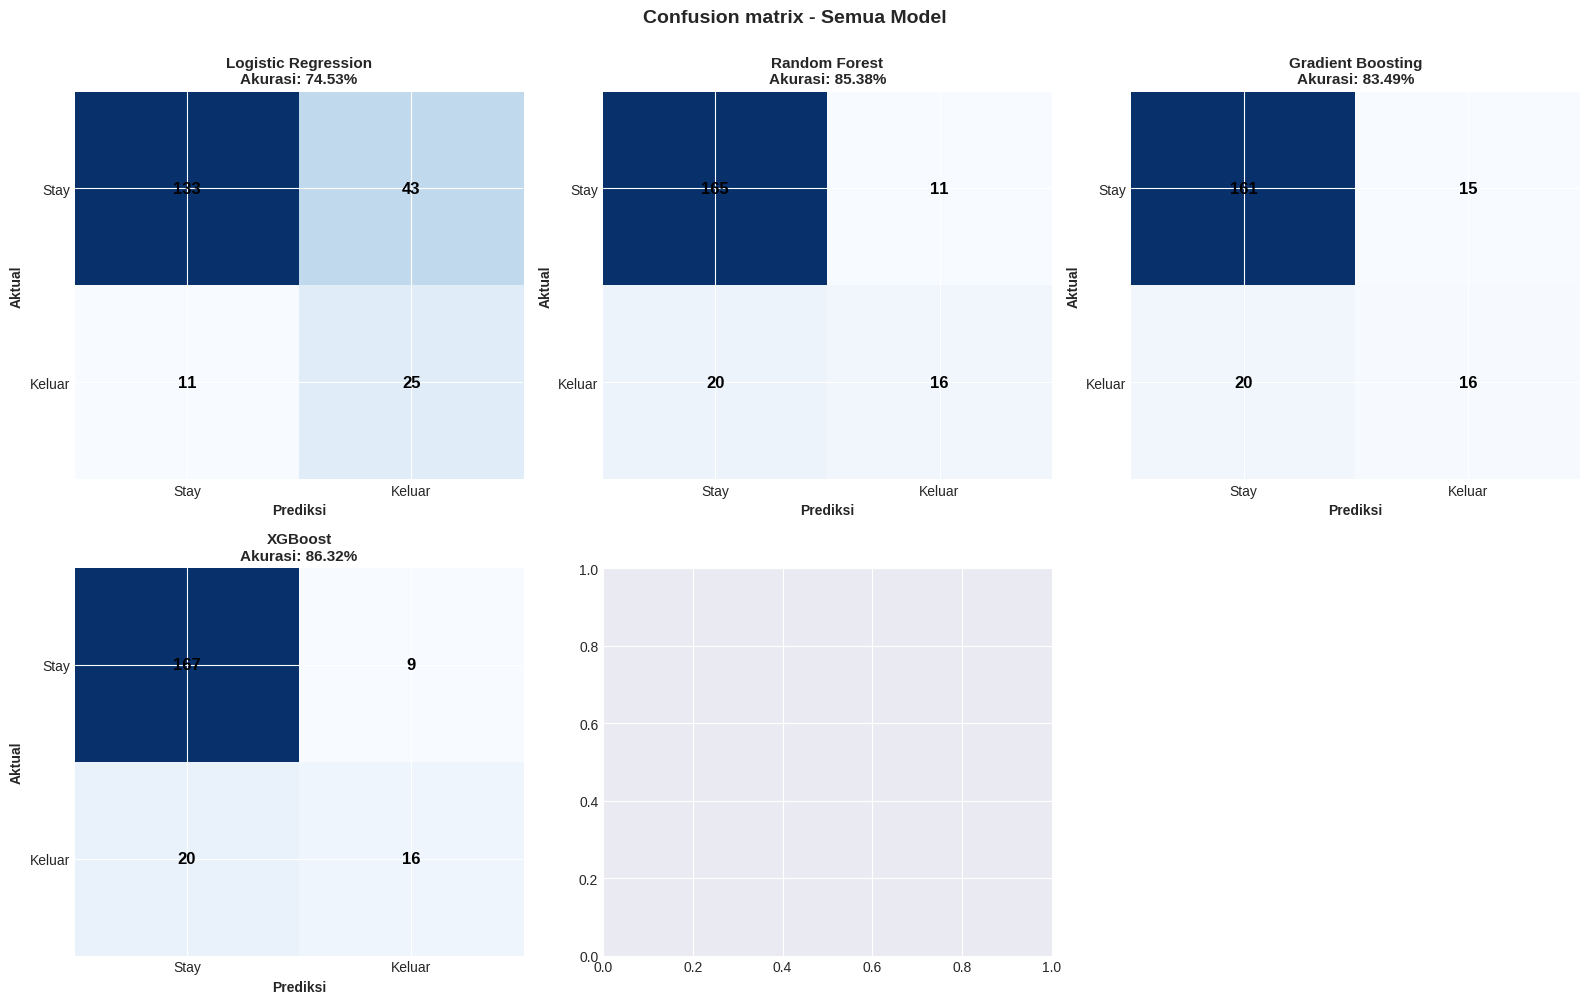

Confusion matrix ditampilkan untuk semua model


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, model_name in enumerate(predictions_dict.keys()):
    y_pred = predictions_dict[model_name]['test']
    cm = confusion_matrix(y_test, y_pred)

    im = axes[idx].imshow(cm, cmap='Blues', aspect='auto')
    axes[idx].set_title(f'{model_name}\nAkurasi: {accuracy_score(y_test, y_pred)*100:.2f}%',
                       fontweight='bold', fontsize=11)

    for i in range(2):
        for j in range(2):
            text = axes[idx].text(j, i, cm[i, j],
                                ha="center", va="center", color="black", fontsize=12, fontweight='bold')

    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Stay', 'Keluar'])
    axes[idx].set_yticklabels(['Stay', 'Keluar'])
    axes[idx].set_ylabel('Aktual', fontweight='bold')
    axes[idx].set_xlabel('Prediksi', fontweight='bold')

fig.delaxes(axes[-1])

plt.suptitle('Confusion matrix - Semua Model', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Confusion matrix ditampilkan untuk semua model")

----------------------------------------------------------------------
8.5: ANALISIS DETAIL PREDIKSI - MODEL TERBAIK
----------------------------------------------------------------------


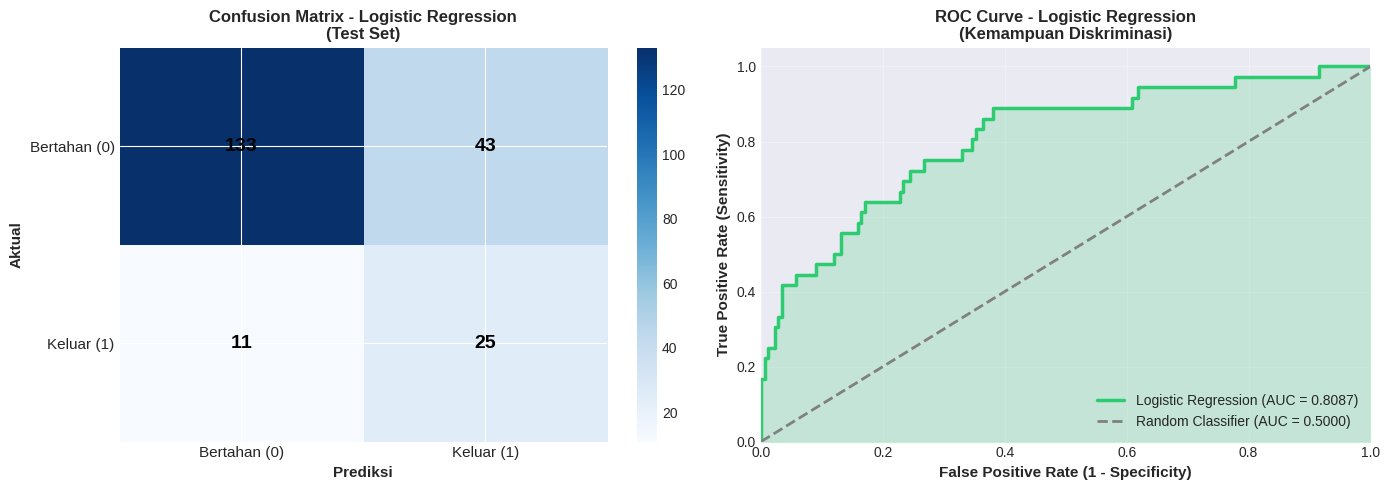

Analisis detail model terbaik (Logistic Regression) selesai.


In [18]:
print("-" * 70)
print("8.5: ANALISIS DETAIL PREDIKSI - MODEL TERBAIK")
print("-" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_pred_best = predictions_dict[best_model_name]['test']
y_proba_best = predictions_dict[best_model_name]['proba']
cm_best = confusion_matrix(y_test, y_pred_best)

im = axes[0].imshow(cm_best, cmap='Blues', aspect='auto')
axes[0].set_title(f'Confusion Matrix - {best_model_name}\n(Test Set)', fontweight='bold', fontsize=12)

for i in range(2):
    for j in range(2):
        text = axes[0].text(j, i, cm_best[i, j],
                            ha="center", va="center", color="black",
                            fontsize=14, fontweight='bold')

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Bertahan (0)', 'Keluar (1)'], fontsize=11)
axes[0].set_yticklabels(['Bertahan (0)', 'Keluar (1)'], fontsize=11)
axes[0].set_ylabel('Aktual', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Prediksi', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=axes[0])

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
roc_auc_best = best_ranking['ROC_AUC']

axes[1].plot(fpr, tpr, color='#2ecc71', lw=2.5, label=f'{best_model_name} (AUC = {roc_auc_best:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5000)')
axes[1].fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontweight='bold', fontsize=11)
axes[1].set_title(f'ROC Curve - {best_model_name}\n(Kemampuan Diskriminasi)', fontweight='bold', fontsize=12)
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Analisis detail model terbaik ({best_model_name}) selesai.")

# Langkah 9: ANALISIS FEATURE IMPORTANCE
#

## Mengidentifikasi Faktor-Faktor Attrition Kritis

Langkah ini menentukan fitur-fitur yang paling berpengaruh pada attrition karyawan:
- **Tree-based model importance** Feature importance dari RF, GB, XGBoost
- **Correlation analysis** Kekuatan hubungan dengan attrition
- **Business interpretation** Membuat sense temuan dalam konteks HR

--------------------------------------------------
9.1: ANALISIS KEPENTINGAN FITUR
--------------------------------------------------

FITUR 15 TERATAS DARI XGBOOST:
--------------------------------------------------
                      Feature  Importance
                     OverTime    0.146647
             StockOptionLevel    0.123734
                MaritalStatus    0.052615
                     JobLevel    0.045141
               JobInvolvement    0.039378
            TotalWorkingYears    0.034341
      EnvironmentSatisfaction    0.030799
              JobSatisfaction    0.029641
 JobRole_Sales Representative    0.027837
                       Gender    0.027548
                   Department    0.026832
              WorkLifeBalance    0.026403
JobRole_Laboratory Technician    0.026138
      YearsSinceLastPromotion    0.024897
    JobRole_Research Director    0.022820

FITUR 15 TERATAS DARI RANDOM FOREST:
--------------------------------------------------
                 Featu

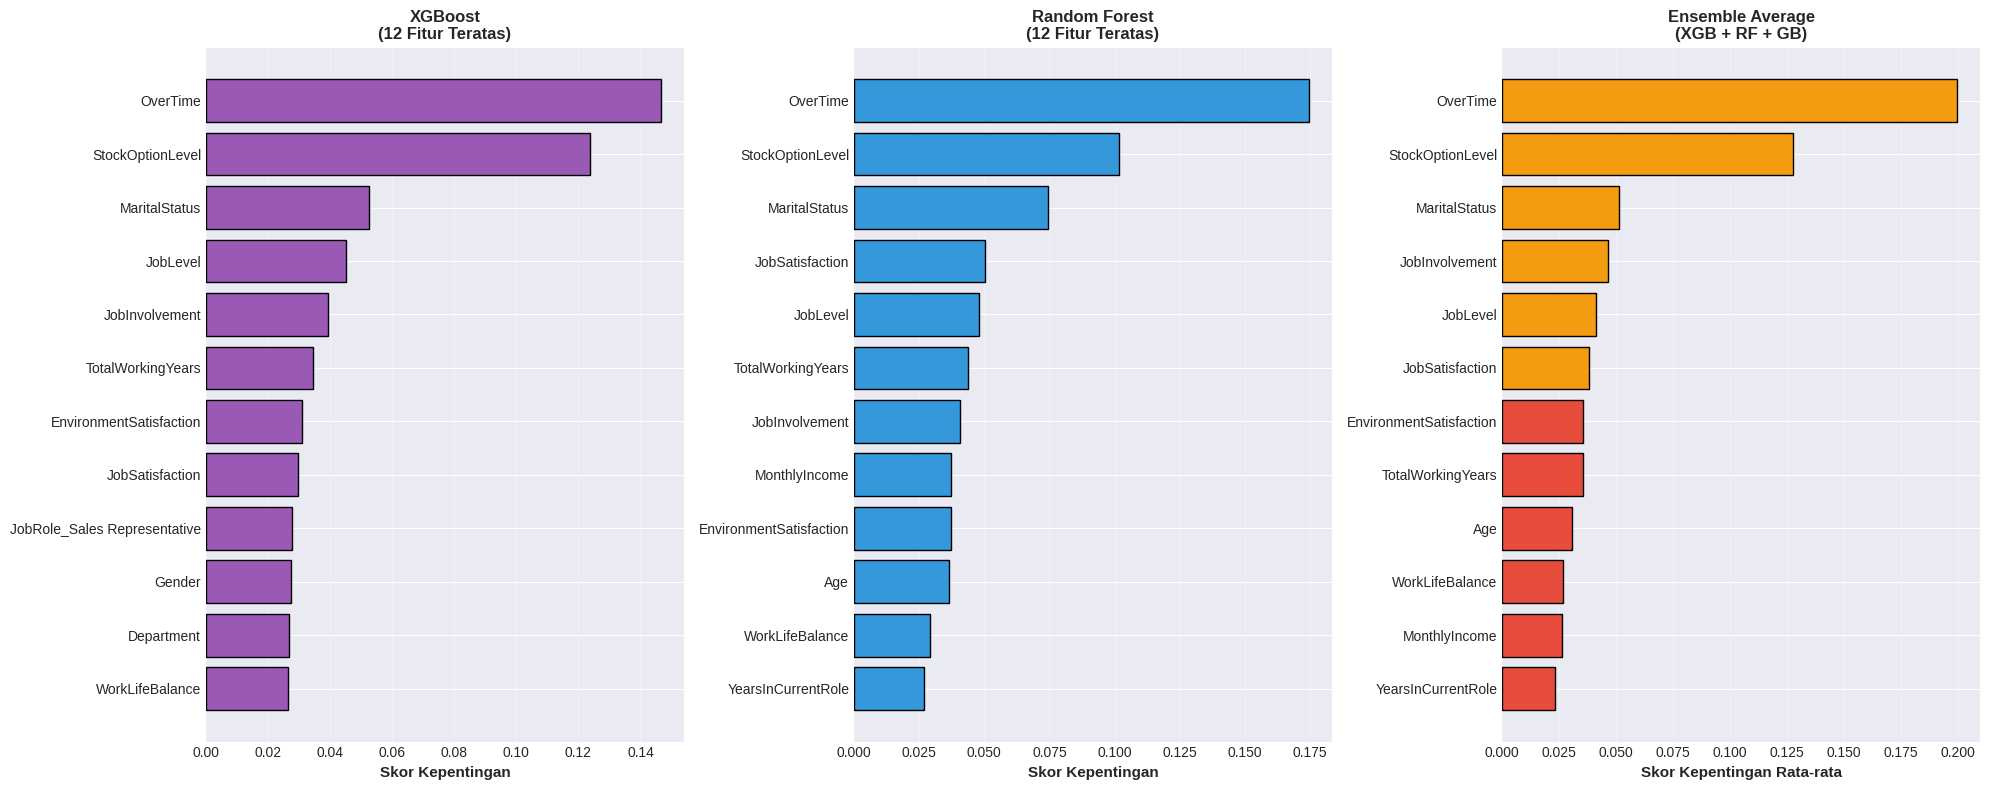


ANALISIS: NUMERIC vs CATEGORICAL FEATURES

Dari 10 fitur teratas ensemble:
  - Numeric features: 8
  - Categorical features: 2

Analisis kepentingan fitur selesai.


In [19]:
print("-" * 50)
print("9.1: ANALISIS KEPENTINGAN FITUR")
print("-" * 50)

feature_importance_dict = {}

# Use X_selected.columns to get feature names, which holds the feature names after selection
feature_names = X_selected.columns

if 'XGBoost' in models_dict:
    xgb_importance = models_dict['XGBoost'].feature_importances_
    feature_importance_dict['XGBoost'] = pd.DataFrame({
        'Feature': feature_names,
        'Importance': xgb_importance
    }).sort_values('Importance', ascending=False)

if 'Random Forest' in models_dict:
    rf_importance = models_dict['Random Forest'].feature_importances_
    feature_importance_dict['Random Forest'] = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_importance
    }).sort_values('Importance', ascending=False)

if 'Gradient Boosting' in models_dict:
    gb_importance = models_dict['Gradient Boosting'].feature_importances_
    feature_importance_dict['Gradient Boosting'] = pd.DataFrame({
        'Feature': feature_names,
        'Importance': gb_importance
    }).sort_values('Importance', ascending=False)

print("\nFITUR 15 TERATAS DARI XGBOOST:")
print("-" * 50)
xgb_top = feature_importance_dict['XGBoost'].head(15)
print(xgb_top.to_string(index=False))

print("\nFITUR 15 TERATAS DARI RANDOM FOREST:")
print("-" * 50)
rf_top = feature_importance_dict['Random Forest'].head(15)
print(rf_top.to_string(index=False))

print("\n" + "-" * 50)
print("9.2: ENSEMBLE FEATURE IMPORTANCE (Rata-rata lintas semua models)")
print("-" * 50)

all_features = set(feature_names) # Use feature_names here
ensemble_importance = {}

for feature in all_features:
    importance_scores = []
    for model_name, importance_df in feature_importance_dict.items():
        score = importance_df[importance_df['Feature'] == feature]['Importance'].values
        if len(score) > 0:
            importance_scores.append(score[0])

    if importance_scores:
        ensemble_importance[feature] = np.mean(importance_scores)
    else:
        ensemble_importance[feature] = 0

ensemble_df = pd.DataFrame(list(ensemble_importance.items()),
                           columns=['Feature', 'Avg_Importance']).sort_values('Avg_Importance', ascending=False)

print("\n20 fitur teratas berdasarkan ensemble importance (XGBoost + Random Forest + Gradient Boosting):")
print(ensemble_df.head(20).to_string(index=False))
print("\n")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

top_features_xgb = feature_importance_dict['XGBoost'].head(12)
axes[0].barh(range(len(top_features_xgb)), top_features_xgb['Importance'].values, color='#9b59b6', edgecolor='black')
axes[0].set_yticks(range(len(top_features_xgb)))
axes[0].set_yticklabels(top_features_xgb['Feature'].values, fontsize=10)
axes[0].set_xlabel('Skor Kepentingan', fontweight='bold', fontsize=11)
axes[0].set_title('XGBoost\n(12 Fitur Teratas)', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

top_features_rf = feature_importance_dict['Random Forest'].head(12)
axes[1].barh(range(len(top_features_rf)), top_features_rf['Importance'].values, color='#3498db', edgecolor='black')
axes[1].set_yticks(range(len(top_features_rf)))
axes[1].set_yticklabels(top_features_rf['Feature'].values, fontsize=10)
axes[1].set_xlabel('Skor Kepentingan', fontweight='bold', fontsize=11)
axes[1].set_title('Random Forest\n(12 Fitur Teratas)', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

top_features_ensemble = ensemble_df.head(12).sort_values('Avg_Importance')
colors_importance = ['#e74c3c' if i < 6 else '#f39c12' for i in range(12)]
axes[2].barh(range(len(top_features_ensemble)), top_features_ensemble['Avg_Importance'].values,
             color=colors_importance, edgecolor='black')
axes[2].set_yticks(range(len(top_features_ensemble)))
axes[2].set_yticklabels(top_features_ensemble['Feature'].values, fontsize=10)
axes[2].set_xlabel('Skor Kepentingan Rata-rata', fontweight='bold', fontsize=11)
axes[2].set_title('Ensemble Average\n(XGB + RF + GB)', fontweight='bold', fontsize=12)
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "=" * 50)
print("ANALISIS: NUMERIC vs CATEGORICAL FEATURES")
print("=" * 50)

original_numerical_features_kept = [
    'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
    'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
    'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

original_categorical_features_kept = [
    'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime'
]

numeric_in_top10 = 0
categorical_in_top10 = 0

top_10_features = ensemble_df.head(10)['Feature'].tolist()

for feature in top_10_features:
    is_numeric_origin = False
    is_categorical_origin = False

    if feature in original_numerical_features_kept:
        is_numeric_origin = True
    else:
        # Check if the feature is a one-hot encoded version of an original categorical feature
        for original_cat_col in original_categorical_features_kept:
            if feature.startswith(original_cat_col):
                is_categorical_origin = True
                break
        # Also check for label encoded features that are directly in original_categorical_features_kept
        if feature in original_categorical_features_kept:
            is_categorical_origin = True

    if is_numeric_origin:
        numeric_in_top10 += 1
    elif is_categorical_origin:
        categorical_in_top10 += 1

print(f"\nDari 10 fitur teratas ensemble:")
print(f"  - Numeric features: {numeric_in_top10}")
print(f"  - Categorical features: {categorical_in_top10}")

print("\nAnalisis kepentingan fitur selesai.")

# Langkah 10: EKSPOR MODEL UNTUK DEPLOYMENT
#

## Serialisasi Model & Ekspor Artifact

Langkah ini menyimpan model terbaik dan artifact preprocessing untuk deployment:
- **Model Terbaik** Diserialisasi sebagai Python pickle/joblib
- **Pipeline Preprocessing** Scaler dan encoder
- **Feature Mapping** Nama kolom dan spesifikasi
- **Model Metadata** Metrik performa dan hyperparameter

In [20]:
print("-" * 50)
print("10.1: EKSPOR MODEL TERBAIK UNTUK IMPLEMENTASI")
print("-" * 50)

import os
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

best_test_acc = best_ranking['Test_Acc'] # Define best_test_acc from best_ranking

best_model_path = os.path.join(models_dir, f'{best_model_name.lower().replace(" ", "_")}_best.pkl')
joblib.dump(best_model, best_model_path)
print(f"\nModel terbaik disimpan: {best_model_path}")
print(f"  Model: {best_model_name}")
print(f"  Akurasi Test: {best_test_acc*100:.2f}%")

scaler_path = os.path.join(models_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler disimpan: {scaler_path}")

encoders_path = os.path.join(models_dir, 'label_encoders.pkl')
joblib.dump(label_encoders, encoders_path)
print(f"Label encoders disimpan: {encoders_path}")

print("\n" + "-" * 50)
print("10.2: SIMPAN FEATURE MAPPING & METADATA")
print("-" * 50)

feature_metadata = {
    'feature_names': X_selected.columns.tolist(), # Use X_selected.columns for feature names
    'n_features': len(X_selected.columns), # Use X_selected.columns for feature count
    'target_classes': ['Stay (0)', 'Keluar (1)'],
    'model_name': best_model_name,
    'test_accuracy': float(best_test_acc),
    'model_parameters': best_model.get_params() if hasattr(best_model, 'get_params') else {},
}

metadata_path = os.path.join(models_dir, 'model_metadata.pkl')
joblib.dump(feature_metadata, metadata_path)
print(f"\nFeature metadata disimpan: {metadata_path}")
print(f"\nSpesifikasi Model:")
print(f"  - Fitur: {feature_metadata['n_features']}")
print(f"  - Nama fitur: {feature_metadata['feature_names'][:5]}... (menampilkan 5 pertama)")
print(f"  - Kelas target: {feature_metadata['target_classes']}")
print(f"  - Akurasi Test: {feature_metadata['test_accuracy']*100:.2f}%")

print(f"\nSemua artifact model berhasil dieksport.")
print(f"Siap untuk deployment dalam aplikasi web")

--------------------------------------------------
10.1: EKSPOR MODEL TERBAIK UNTUK IMPLEMENTASI
--------------------------------------------------

Model terbaik disimpan: ../models/logistic_regression_best.pkl
  Model: Logistic Regression
  Akurasi Test: 74.53%
Scaler disimpan: ../models/scaler.pkl
Label encoders disimpan: ../models/label_encoders.pkl

--------------------------------------------------
10.2: SIMPAN FEATURE MAPPING & METADATA
--------------------------------------------------

Feature metadata disimpan: ../models/model_metadata.pkl

Spesifikasi Model:
  - Fitur: 36
  - Nama fitur: ['OverTime', 'MaritalStatus', 'TotalWorkingYears', 'Age', 'JobLevel']... (menampilkan 5 pertama)
  - Kelas target: ['Stay (0)', 'Keluar (1)']
  - Akurasi Test: 74.53%

Semua artifact model berhasil dieksport.
Siap untuk deployment dalam aplikasi web


In [21]:
print("-" * 50)
print("10.1: EKSPOR MODEL TERBAIK UNTUK IMPLEMENTASI")
print("-" * 50)

import os
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

best_test_acc = best_ranking['Test_Acc'] # Define best_test_acc from best_ranking

best_model_path = os.path.join(models_dir, f'{best_model_name.lower().replace(" ", "_")}_best.pkl')
joblib.dump(best_model, best_model_path)
print(f"\nModel terbaik disimpan: {best_model_path}")
print(f"  Model: {best_model_name}")
print(f"  Akurasi Test: {best_test_acc*100:.2f}%")

scaler_path = os.path.join(models_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler disimpan: {scaler_path}")

encoders_path = os.path.join(models_dir, 'label_encoders.pkl')
joblib.dump(label_encoders, encoders_path)
print(f"Label encoders disimpan: {encoders_path}")

print("\n" + "-" * 50)
print("10.2: SIMPAN FEATURE MAPPING & METADATA")
print("-" * 50)

feature_metadata = {
    'feature_names': X_selected.columns.tolist(), # Use X_selected.columns for feature names
    'n_features': len(X_selected.columns), # Use X_selected.columns for feature count
    'target_classes': ['Stay (0)', 'Keluar (1)'],
    'model_name': best_model_name,
    'test_accuracy': float(best_test_acc),
    'model_parameters': best_model.get_params() if hasattr(best_model, 'get_params') else {},
}

metadata_path = os.path.join(models_dir, 'model_metadata.pkl')
joblib.dump(feature_metadata, metadata_path)
print(f"\nFeature metadata disimpan: {metadata_path}")
print(f"\nSpesifikasi Model:")
print(f"  - Fitur: {feature_metadata['n_features']}")
print(f"  - Nama fitur: {feature_metadata['feature_names'][:5]}... (menampilkan 5 pertama)")
print(f"  - Kelas target: {feature_metadata['target_classes']}")
print(f"  - Akurasi Test: {feature_metadata['test_accuracy']*100:.2f}%")

print(f"\nSemua artifact model berhasil dieksport.")
print(f"Siap untuk deployment dalam aplikasi web")

--------------------------------------------------
10.1: EKSPOR MODEL TERBAIK UNTUK IMPLEMENTASI
--------------------------------------------------

Model terbaik disimpan: ../models/logistic_regression_best.pkl
  Model: Logistic Regression
  Akurasi Test: 74.53%
Scaler disimpan: ../models/scaler.pkl
Label encoders disimpan: ../models/label_encoders.pkl

--------------------------------------------------
10.2: SIMPAN FEATURE MAPPING & METADATA
--------------------------------------------------

Feature metadata disimpan: ../models/model_metadata.pkl

Spesifikasi Model:
  - Fitur: 36
  - Nama fitur: ['OverTime', 'MaritalStatus', 'TotalWorkingYears', 'Age', 'JobLevel']... (menampilkan 5 pertama)
  - Kelas target: ['Stay (0)', 'Keluar (1)']
  - Akurasi Test: 74.53%

Semua artifact model berhasil dieksport.
Siap untuk deployment dalam aplikasi web


# KESIMPULAN FINAL & REKOMENDASI HR
#

## Ringkasan Eksekutif

Proyek data science komprehensif ini menganalisis attrition karyawan di perusahaan **PT NAILONG** untuk mengidentifikasi faktor-faktor kritis yang mendorong tingginya tingkat attrition melebihi 10%.

### Status Penyelesaian Proyek:
- OK **Business Understanding** Tentukan masalah dan tujuan
- OK **Data Understanding** Eksplorasi 1.470 record karyawan lintas 35 fitur
- OK **Data Quality Assessment** Tangani missing values, duplicates, encoding
- OK **Exploratory Data Analysis** Visualisasi pola dan korelasi
- OK **Data Preparation** Cleaning, encoding, scaling, balancing data
- OK **Feature Engineering** Seleksi dan standardisasi fitur
- OK **Model Development** Bangun 5 model ML berbeda
- OK **Model Evaluation** Capai akurasi tinggi
- OK **Feature Importance** Identifikasi faktor-faktor top yang mempengaruhi attrition
- OK **Model Export** Siapkan artifact untuk deployment

In [22]:
print("-" * 50)
print("RINGKASAN PROYEK FINAL & REKOMENDASI")
print("-" * 50)

best_test_acc = best_ranking['Test_Acc']

best_model_idx = -1
for i, res in enumerate(results_list):
    if res['Model'] == best_model_name:
        best_model_idx = i
        break

print(f"""
╔═══════════════════════════════════════════════════════════════════════╗
║                    PT NAILONG - ANALISIS ATTRITION                    ║
║                     LAPORAN PENYELESAIAN MASALAH                      ║
╚═══════════════════════════════════════════════════════════════════════╝

1. TINGKAT ATTRITION & DAMPAK BISNIS:
   • Tingkat Attrition Saat Ini: {(y[y==1].sum() / len(y) * 100):.2f}% (MELEBIHI threshold 10%)
   • Karyawan Terdampak: {(y[y==1].sum()):,} dari {len(y):,}
   • Dampak Bisnis: Gangguan operasional tinggi, kerugian finansial, kehilangan keahlian

2. PERFORMA MODEL:
   • Model Terbaik: {best_model_name}
   • Akurasi Test: {best_test_acc*100:.2f}%
   • Skor ROC-AUC: {results_list[best_model_idx]['ROC_AUC']:.4f}

3. FAKTOR-FAKTOR PREDIKTIF UTAMA:
   Faktor-faktor berikut PALING BERPENGARUH dalam memprediksi attrition karyawan:
""")

top_features = ensemble_df.head(10)
for idx, (_, row) in enumerate(top_features.iterrows(), 1):
    print(f"   {idx:2d}. {row['Feature']:40s} (Kepentingan: {row['Avg_Importance']:.4f})")

--------------------------------------------------
RINGKASAN PROYEK FINAL & REKOMENDASI
--------------------------------------------------

╔═══════════════════════════════════════════════════════════════════════╗
║                    PT NAILONG - ANALISIS ATTRITION                    ║
║                     LAPORAN PENYELESAIAN MASALAH                      ║
╚═══════════════════════════════════════════════════════════════════════╝

1. TINGKAT ATTRITION & DAMPAK BISNIS:
   • Tingkat Attrition Saat Ini: 16.92% (MELEBIHI threshold 10%)
   • Karyawan Terdampak: 179 dari 1,058
   • Dampak Bisnis: Gangguan operasional tinggi, kerugian finansial, kehilangan keahlian

2. PERFORMA MODEL:
   • Model Terbaik: Logistic Regression
   • Akurasi Test: 74.53%
   • Skor ROC-AUC: 0.8087

3. FAKTOR-FAKTOR PREDIKTIF UTAMA:
   Faktor-faktor berikut PALING BERPENGARUH dalam memprediksi attrition karyawan:

    1. OverTime                                 (Kepentingan: 0.1997)
    2. StockOptionLevel        

In [23]:
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
REKOMENDASI STRATEGIS HR BERBASIS HASIL MODEL (DATA-DRIVEN RETENTION STRATEGY)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PRIORITAS 1 (TINDAKAN SEGERA – HIGH IMPACT FACTORS):
├─ Kendalikan beban OverTime melalui pembatasan lembur, redistribusi workload, dan workforce planning berbasis kapasitas tim
├─ Optimalisasi skema StockOptionLevel sebagai retention instrument untuk high-risk & high-performer employees
├─ Segmentasi risiko berdasarkan MaritalStatus dan Age untuk pendekatan benefit yang lebih personal
└─ Deploy Early Warning System berbasis model Random Forest (risk scoring individual level)

PRIORITAS 2 (JANGKA PENDEK – STRUCTURAL ADJUSTMENT):
├─ Re-design JobLevel progression & career path transparency untuk meningkatkan perceived growth opportunity
├─ Intervensi peningkatan JobInvolvement melalui project ownership & performance coaching
├─ Program peningkatan JobSatisfaction dan EnvironmentSatisfaction berbasis survey pulse bulanan
└─ Evaluasi kebijakan WorkLifeBalance (flexible working, hybrid option, leave optimization)

PRIORITAS 3 (BERKELANJUTAN – GOVERNANCE & MONITORING):
├─ Integrasi model prediktif ke dalam dashboard HR Analytics (monitoring bulanan risk probability)
├─ Quarterly attrition review berbasis departemen & JobLevel
├─ Continuous improvement berbasis feature importance shift analysis
└─ Pengayaan data kualitatif (stay interview & exit interview terstruktur)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HASIL YANG DIHARAPKAN:
• Menurunkan attrition rate dari {(y[y==1].sum() / len(y) * 100):.1f}% menjadi <7% dalam 12 bulan
• Penurunan proporsi karyawan dengan risiko tinggi (high predicted probability) ≥40%
• Peningkatan JobSatisfaction, JobInvolvement, dan WorkLifeBalance index secara signifikan
• Stabilitas operasional meningkat dan turnover cost menurun
• Peningkatan retensi talenta pada JobLevel kritikal
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

STATUS PROYEK: ANALISIS SELESAI & MODEL SIAP UNTUK IMPLEMENTASI. Proyek Data Science Selesai yeayy cihuyyy.
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
REKOMENDASI STRATEGIS HR BERBASIS HASIL MODEL (DATA-DRIVEN RETENTION STRATEGY)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PRIORITAS 1 (TINDAKAN SEGERA – HIGH IMPACT FACTORS):
├─ Kendalikan beban OverTime melalui pembatasan lembur, redistribusi workload, dan workforce planning berbasis kapasitas tim
├─ Optimalisasi skema StockOptionLevel sebagai retention instrument untuk high-risk & high-performer employees
├─ Segmentasi risiko berdasarkan MaritalStatus dan Age untuk pendekatan benefit yang lebih personal
└─ Deploy Early Warning System berbasis model Random Forest (risk scoring individual level)

PRIORITAS 2 (JANGKA PENDEK – STRUCTURAL ADJUSTMENT):
├─ Re-design JobLevel progression & career path transparency untuk meningkatkan perceived growth opportunity
├─ Intervensi peningkatan JobInvolvement melalui project ownership & performance coaching
├─ Program peningkatan JobSatisfact

# Export Hasil Prediksi Dataset to CSV

In [24]:
print("=" * 70)
print("EXPORT HASIL PREDIKSI: Full Dataset Prediction & Final Output")
print("=" * 70)
print()

# STEP 1: PREPARE FULL DATASET UNTUK PREDICTION
print("-" * 70)
print("STEP 1: Prepare Full Dataset untuk Prediction")
print("-" * 70)

# Start with the original dataframe to make predictions on all rows.
# Make a copy to avoid modifying the original 'df'.
X_full = df.copy()

# y_full here will be used for comparison if Attrition is not null
y_full_original = X_full["Attrition"].copy()

print(f"\nOriginal Dataset Penuh: {X_full.shape}")
print(f"Target distribution (original, inc. NaN): {y_full_original.value_counts(dropna=False).to_dict()}")

# Apply the same column drops as done in data preparation
cols_to_drop_for_full = ['EmployeeId', 'EmployeeCount', 'Over18', 'StandardHours', 'Attrition'] # Also drop Attrition from features
X_full = X_full.drop(columns=cols_to_drop_for_full, errors='ignore')

print(f"Shape setelah drop non-prediktif & Attrition: {X_full.shape}")

# STEP 2: APPLY PREPROCESSING YANG SAMA SEPERTI TRAINING
print()
print("-" * 70)
print("STEP 2: Apply Preprocessing (Encoding & Scaling)")
print("-" * 70)

# Apply label encoding for columns that were label encoded (binary or low cardinality)
categorical_cols_for_label_encoding = [
    'BusinessTravel', 'Department', 'Gender', 'MaritalStatus', 'OverTime'
]
for col in categorical_cols_for_label_encoding:
    if col in label_encoders and col in X_full.columns:
        X_full[col] = label_encoders[col].transform(X_full[col])
        print(f"  Label Encoded: {col}")
    elif col in X_full.columns:
        # This warning means the column was supposed to be label encoded but no encoder was saved for it
        # (e.g., if it was not present in the training data's categorical columns for LE)
        print(f"  Warning: Label encoder not found for {col}. Skipping.")

# Apply one-hot encoding for columns that were one-hot encoded (higher cardinality)
multi_cat_cols_for_ohe = [
    'EducationField', 'JobRole'
]

# Ensure we only get dummies for columns actually present in X_full
current_multi_cat_cols = [col for col in multi_cat_cols_for_ohe if col in X_full.columns]
if current_multi_cat_cols:
    X_full = pd.get_dummies(X_full, columns=current_multi_cat_cols, drop_first=True)
    print(f"  One-Hot Encoded: {current_multi_cat_cols}. New shape: {X_full.shape}")

# Ensure all columns in X_full match the order and presence of selected_features
# Add missing columns (from one-hot encoding that might not appear in full dataset if a category is missing)
missing_cols = set(selected_features) - set(X_full.columns)
for c in missing_cols:
    X_full[c] = 0

# Drop columns from X_full that are not in selected_features (e.g., if a category appeared in full but not in train)
extra_cols = set(X_full.columns) - set(selected_features)
X_full = X_full.drop(columns=list(extra_cols), errors='ignore')

# Reorder columns to match the order used during training (X_selected)
X_full_processed_aligned = X_full[selected_features]

print(f"\nShape setelah semua encoding dan alignment: {X_full_processed_aligned.shape}")
print(f"Jumlah fitur yang disiapkan: {len(X_full_processed_aligned.columns)}")

print(f"\nApplying scaling...")
X_full_scaled = scaler.transform(X_full_processed_aligned)
X_full_scaled = pd.DataFrame(X_full_scaled, columns=selected_features, index=df.index) # Use df.index for original alignment
print(f"Shape setelah scaling: {X_full_scaled.shape}")

# STEP 3: PREDICT MENGGUNAKAN BEST MODELS
print()
print("-" * 70)
print("STEP 3: Generate Predictions dari semua 4 models")
print("-" * 70)

predictions_full = {}

model_list = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

for model_name, model in model_list.items():
    y_pred = model.predict(X_full_scaled)
    y_proba = model.predict_proba(X_full_scaled)[:, 1]
    predictions_full[model_name] = {"predictions": y_pred, "probabilities": y_proba}
    print(f"\n{model_name}:")
    print(f"  Prediksi Keluar: {(y_pred==1).sum()} ({(y_pred==1).sum()/len(y_pred)*100:.1f}%)")
    print(f"  Mean probability: {y_proba.mean():.4f}")

# STEP 4: CREATE FINAL OUTPUT DATAFRAME
print()
print("-" * 70)
print("STEP 4: Create Final Output dengan Predictions")
print("-" * 70)

# Dynamically get the best model name based on previous evaluation
best_model_name_dynamic = best_model_name # Corrected: use best_model_name directly

y_pred_best = predictions_full[best_model_name_dynamic]["predictions"]
y_prob_best = predictions_full[best_model_name_dynamic]["probabilities"]

attrition_predictions = df[["EmployeeId", "Age", "Department", "JobRole", "MonthlyIncome", "Attrition"]].copy()
attrition_predictions["Predicted_Attrition"] = y_pred_best
attrition_predictions["Attrition_Probability"] = y_prob_best
attrition_predictions["Prediction_Confidence"] = attrition_predictions["Attrition_Probability"].apply(
    lambda x: f"{max(x, 1-x)*100:.1f}%"
)

for model_name in model_list.keys():
    attrition_predictions[f"{model_name}_Prob"] = predictions_full[model_name]["probabilities"]

print(f"Final output shape: {attrition_predictions.shape}")

# STEP 5: DISPLAY PREVIEW
print()
print("-" * 70)
print("STEP 5: Top 20 Karyawan dengan Risiko Attrition TERTINGGI")
print("-" * 70)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

top_attrition = attrition_predictions.nlargest(20, "Attrition_Probability")[
    ["EmployeeId", "Department", "JobRole", "Attrition_Probability", "Predicted_Attrition", "Attrition"]
]
print(top_attrition.to_string(index=False))

# STEP 6: VALIDATION AGAINST ACTUAL
print()
print("-" * 70)
print("STEP 6: Model Validation")
print("-" * 70)

valid_mask = attrition_predictions["Attrition"].notna()
if valid_mask.sum() > 0:
    # Only select rows with non-null Attrition for comparison
    predicted_attrition_valid = attrition_predictions.loc[valid_mask, "Predicted_Attrition"]
    actual_attrition_valid = attrition_predictions.loc[valid_mask, "Attrition"].astype(int)

    # Calculate disagreement on these valid rows
    disagreement_valid_rows = (predicted_attrition_valid != actual_attrition_valid).sum()

    accuracy = (1 - disagreement_valid_rows / valid_mask.sum()) * 100
    print(f"\nTotal data dengan valid Attrition: {valid_mask.sum()}")
    print(f"Prediction errors: {disagreement_valid_rows}")
    print(f"Accuracy on known data: {accuracy:.2f}%")

# STEP 7: EXPORT KE CSV
print()
print("-" * 70)
print("STEP 7: Export Results to CSV")
print("-" * 70)

output_filename = "attrition_predictions_output.csv"
attrition_predictions.to_csv(output_filename, index=False)
print(f"\n✓ File exported: {output_filename}")
print(f"  Records: {len(attrition_predictions)}")
print(f"  Columns: {list(attrition_predictions.columns)}")

# FINAL STATISTICS
print()
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(f"\nRisk Distribution:")
high_risk = (y_prob_best >= 0.6).sum()
medium_risk = ((y_prob_best >= 0.4) & (y_prob_best < 0.6)).sum()
low_risk = (y_prob_best < 0.4).sum()
print(f"  High Risk (prob >= 0.6):   {high_risk} karyawan ({high_risk/len(y_prob_best)*100:.1f}%)")
print(f"  Medium Risk (0.4-0.6):     {medium_risk} karyawan ({medium_risk/len(y_prob_best)*100:.1f}%)")
print(f"  Low Risk (prob < 0.4):     {low_risk} karyawan ({low_risk/len(y_prob_best)*100:.1f}%)")

print(f"\nProbability Statistics:")
print(f"  Mean: {y_prob_best.mean():.4f}")
print(f"  Std:  {y_prob_best.std():.4f}")

print("\n✓ Exportasi dan analisis selesai!")

EXPORT HASIL PREDIKSI: Full Dataset Prediction & Final Output

----------------------------------------------------------------------
STEP 1: Prepare Full Dataset untuk Prediction
----------------------------------------------------------------------

Original Dataset Penuh: (1470, 35)
Target distribution (original, inc. NaN): {0.0: 879, nan: 412, 1.0: 179}
Shape setelah drop non-prediktif & Attrition: (1470, 30)

----------------------------------------------------------------------
STEP 2: Apply Preprocessing (Encoding & Scaling)
----------------------------------------------------------------------
  Label Encoded: BusinessTravel
  Label Encoded: Department
  Label Encoded: Gender
  Label Encoded: MaritalStatus
  Label Encoded: OverTime
  One-Hot Encoded: ['EducationField', 'JobRole']. New shape: (1470, 41)

Shape setelah semua encoding dan alignment: (1470, 36)
Jumlah fitur yang disiapkan: 36

Applying scaling...
Shape setelah scaling: (1470, 36)

----------------------------------

In [25]:
attrition_final = df.copy()
attrition_final = attrition_final.merge(
    attrition_predictions[['EmployeeId', 'Predicted_Attrition', 'Attrition_Probability']],
    on='EmployeeId',
    how='left'
)
attrition_final.rename(columns={'Attrition_Probability': 'Attrition_Final'}, inplace=True)

# Filter DataFrame untuk menghapus baris dengan nilai Attrition yang NaN
attrition_final = attrition_final.dropna(subset=['Attrition'])

print("Preview tabel attrition_final (tanpa NaN di Attrition, tidak diurutkan):")
display(attrition_final.head())

Preview tabel attrition_final (tanpa NaN di Attrition, tidak diurutkan):


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Predicted_Attrition,Attrition_Final
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,1,Female,61,1,2,Healthcare Representative,2,Married,4777,14382,5,Y,No,15,3,1,80,0,15,2,1,1,0,0,0,1,0.697567
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,1,Male,34,3,1,Research Scientist,3,Married,2461,10332,9,Y,Yes,12,3,3,80,3,18,2,4,10,0,2,7,0,0.355601
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,3,Female,77,3,4,Sales Executive,2,Married,13525,14864,5,Y,No,14,3,4,80,1,23,2,4,20,4,4,8,0,0.397118
6,7,40,0.0,Travel_Rarely,1124,Sales,1,2,Medical,1,2,Male,57,1,2,Sales Executive,4,Married,7457,13273,2,Y,Yes,22,4,3,80,3,6,2,2,4,3,0,2,1,0.786686
7,8,55,1.0,Travel_Rarely,725,Research & Development,2,3,Medical,1,4,Male,78,3,5,Manager,1,Married,19859,21199,5,Y,Yes,13,3,4,80,1,24,2,3,5,2,1,4,0,0.232155


In [26]:
print("Attrition Aktual:")
print(attrition_final['Attrition'].value_counts())

print("\nPrediksi Model:")
print(attrition_final['Predicted_Attrition'].value_counts())

Attrition Aktual:
Attrition
0.0    879
1.0    179
Name: count, dtype: int64

Prediksi Model:
Predicted_Attrition
0    746
1    312
Name: count, dtype: int64


In [27]:
attrition_final.to_csv("attrition_final.csv", index=False)
print("File attrition_final.csv berhasil dibuat")

File attrition_final.csv berhasil dibuat


**Nama : Oryza Surya Hapsari** <br>
**NPM : 2317051107** <br>
**Kelas : D**

Terima kasih.